### Tennessee

BYM and BYM-TDA 

In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt


from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve
import geopandas as gpd

# these libraries are not dependencies of pymc
import networkx as nx
import nutpie
import libpysal as ps

In [2]:
RANDOM_SEED = 8926
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
current_path = os.getcwd()

In [4]:
save_path = "/Users/h6x/CODE/Archive/git/spatial-risk-tda/plots/disease_modeling_multi_variable/tn"

In [5]:
state_abb = "TN"
state_abb_lower = state_abb.lower()

Load the data

In [6]:
# SVI
svi_tda_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"tda_summaries_2018_{state_abb}_down.csv"), dtype={'STCNTY': str})

# SMR
smr_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"smr_data_2018_{state_abb}.csv"), dtype={'FIPS': str})

# GEO: get geometry data
geo_data = gpd.read_file(os.path.join(current_path, "data", "raw_data", "SVI2018_US_county.gdb"), dtype={"FIPS": str})

geo_data = geo_data[['FIPS', 'geometry','ST_ABBR']]

/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DTYPE
  return ogr_read(


In [7]:
# combine smr on FIPS and svi data on STCNTY - left
combined_data = pd.merge(smr_data, svi_tda_data, left_on="FIPS", right_on="STCNTY", how="left")

# merge combined data with geo data
combined_data = pd.merge(combined_data, geo_data, on="FIPS", how="left")

In [8]:
# print the shape
print(f"Shape of the combined data: {combined_data.shape}")

Shape of the combined data: (95, 89)


In [9]:
# get the 'state' data

combined_data = combined_data[combined_data['ST_ABBR'] == state_abb]

In [10]:
combined_data.shape

(95, 89)

In [11]:
# Adding this just to plot original data!
# Replace 0 with NaN in observed_deaths column
combined_data_map = combined_data.copy()
combined_data_map["observed_deaths"] = combined_data_map["observed_deaths"].replace(0.0, np.nan)

gdf_map = gpd.GeoDataFrame(combined_data_map, geometry='geometry')

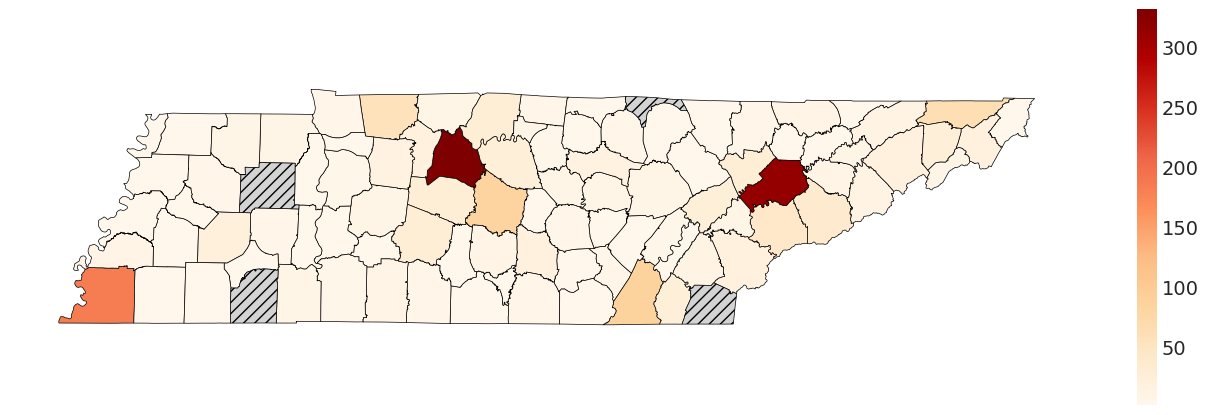

In [12]:
import matplotlib.pyplot as plt
import geopandas as gpd

# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf_map.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"observed_deaths.png"), bbox_inches='tight', dpi=300)

Cleaning the data: Removing the rows with missing observed deaths, islands, few states

In [13]:
# filter by column to have columns start with EP_ or SMR and geometry and FIPS and observed_death and expected_death
combined_data = combined_data.filter(regex='EP_|SMR|geometry|FIPS|observed_death|expected_death')

# drop the rows with observed_death = 0
combined_data = combined_data[combined_data['observed_deaths'] > 0]

# make it a geodataframe
gdf = gpd.GeoDataFrame(combined_data, geometry='geometry')

# Compute Queen adjacency
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# if we keep the islands it will cause error in the adjacency computation(empty adjacencies)
# Get the islands fips to a list
islands = w.islands

# drop the islands
combined_data = combined_data[~combined_data["FIPS"].isin(islands)]

# drop rows with FIPS starts with 72, 78, 02, 15, 60
combined_data = combined_data[~combined_data['FIPS'].str.startswith(('72', '78', '02', '15', '60'))]

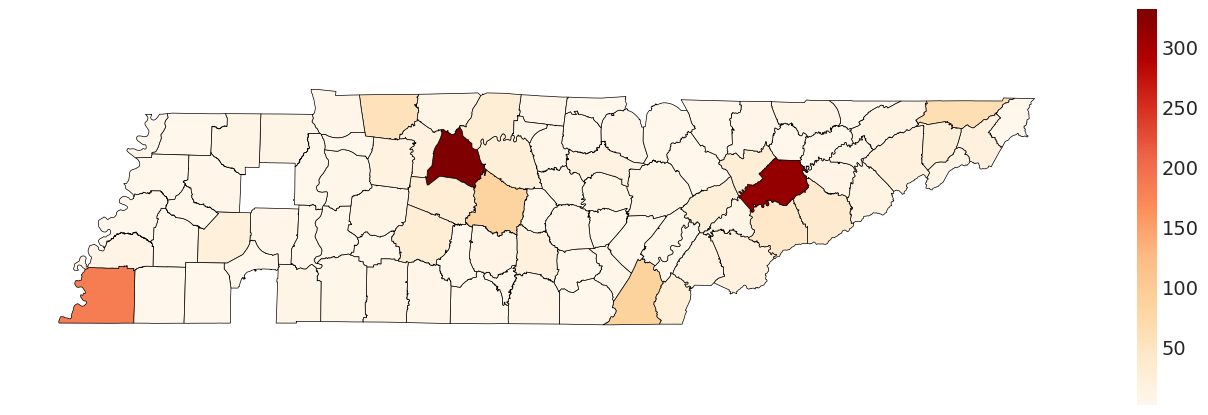

In [14]:
# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.show()

Combine TDA summaries for each state(all variables)

In [15]:
# get the column names with _AL
al_cols = combined_data.filter(regex='_AL').columns

print(f"Columns with _AL: {al_cols}")

# sum the columns with _AL
combined_data['AL'] = combined_data[al_cols].sum(axis=1)

# drop the columns with _AL
# combined_data.drop(columns=al_cols, inplace=True)

# get the column names with _TL

tl_cols = combined_data.filter(regex='_TL').columns

print(f"Columns with _TL: {tl_cols}")

# sum the columns with _TL
combined_data['TL'] = combined_data[tl_cols].sum(axis=1)

# drop the columns with _TL
# combined_data.drop(columns=tl_cols, inplace=True)

# get the column names with _AML
aml_cols = combined_data.filter(regex='_AML').columns

print(f"Columns with _AML: {aml_cols}")

# sum the columns with _AML
combined_data['AML'] = combined_data[aml_cols].sum(axis=1)

# drop the columns with _AML
# combined_data.drop(columns=aml_cols, inplace=True)

# get the column names with _TML
tml_cols = combined_data.filter(regex='_TML').columns

print(f"Columns with _TML: {tml_cols}")

# sum the columns with _TML
combined_data['TML'] = combined_data[tml_cols].sum(axis=1)

# drop the columns with _TML
# combined_data.drop(columns=tml_cols, inplace=True)

Columns with _AL: Index(['EP_POV_AL', 'EP_UNEMP_AL', 'EP_PCI_AL', 'EP_NOHSDP_AL',
       'EP_UNINSUR_AL', 'EP_AGE65_AL', 'EP_AGE17_AL', 'EP_DISABL_AL',
       'EP_SNGPNT_AL', 'EP_LIMENG_AL', 'EP_MINRTY_AL', 'EP_MUNIT_AL',
       'EP_MOBILE_AL', 'EP_CROWD_AL', 'EP_NOVEH_AL', 'EP_GROUPQ_AL'],
      dtype='object')
Columns with _TL: Index(['EP_POV_TL', 'EP_UNEMP_TL', 'EP_PCI_TL', 'EP_NOHSDP_TL',
       'EP_UNINSUR_TL', 'EP_AGE65_TL', 'EP_AGE17_TL', 'EP_DISABL_TL',
       'EP_SNGPNT_TL', 'EP_LIMENG_TL', 'EP_MINRTY_TL', 'EP_MUNIT_TL',
       'EP_MOBILE_TL', 'EP_CROWD_TL', 'EP_NOVEH_TL', 'EP_GROUPQ_TL'],
      dtype='object')
Columns with _AML: Index(['EP_POV_AML', 'EP_UNEMP_AML', 'EP_PCI_AML', 'EP_NOHSDP_AML',
       'EP_UNINSUR_AML', 'EP_AGE65_AML', 'EP_AGE17_AML', 'EP_DISABL_AML',
       'EP_SNGPNT_AML', 'EP_LIMENG_AML', 'EP_MINRTY_AML', 'EP_MUNIT_AML',
       'EP_MOBILE_AML', 'EP_CROWD_AML', 'EP_NOVEH_AML', 'EP_GROUPQ_AML'],
      dtype='object')
Columns with _TML: Index(['EP_POV_TML', '

Get the adjacency matrix

In [16]:
# create the queen adjacency matrix
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# Spatial adjacency matrix (N x N) with binary entries for neighbor relationships.
# make it into a matrix
W = w.full()[0]

In [17]:
# print the shape of W
print(f"Shape of W: {W.shape}")

Shape of W: (91, 91)


Prepare data and adjacency structures

Final columns after VIF selection: ['EP_UNEMP_AV_ORI', 'EP_AGE65_AV_ORI', 'EP_MINRTY_AV_ORI', 'EP_LIMENG_AV_ORI', 'EP_MUNIT_AV_ORI', 'EP_CROWD_AV_ORI', 'EP_GROUPQ_AV_ORI']

In [18]:
y = combined_data["observed_deaths"].values
E = combined_data["expected_deaths"].values

EP_UNEMP_AV_ORI = combined_data["EP_UNEMP_AV_ORI"].values
EP_MOBILE_AV_ORI = combined_data["EP_MOBILE_AV_ORI"].values
EP_MINRTY_AV_ORI = combined_data["EP_MINRTY_AV_ORI"].values
EP_LIMENG_AV_ORI = combined_data["EP_LIMENG_AV_ORI"].values
EP_MUNIT_AV_ORI = combined_data["EP_MUNIT_AV_ORI"].values
EP_CROWD_AV_ORI = combined_data["EP_CROWD_AV_ORI"].values
EP_GROUPQ_AV_ORI = combined_data["EP_GROUPQ_AV_ORI"].values


EP_UNEMP_AL = combined_data["EP_UNEMP_AL"].values
EP_MOBILE_AL = combined_data["EP_MOBILE_AL"].values
EP_MINRTY_AL = combined_data["EP_MINRTY_AL"].values
EP_LIMENG_AL = combined_data["EP_LIMENG_AL"].values
EP_MUNIT_AL = combined_data["EP_MUNIT_AL"].values
EP_CROWD_AL = combined_data["EP_CROWD_AL"].values
EP_GROUPQ_AL = combined_data["EP_GROUPQ_AL"].values

# combine AL columns into single AL variable
combined_data['AL'] = (EP_UNEMP_AL + EP_MOBILE_AL + EP_MINRTY_AL + EP_LIMENG_AL + EP_MUNIT_AL + EP_CROWD_AL + EP_GROUPQ_AL)

# Mean standerdizing "AL"
mean_value = combined_data['AL'].mean()
std_value = combined_data['AL'].std()
combined_data['AL'] = (combined_data['AL'] - mean_value) / std_value

AL = combined_data["AL"].values


E[E < 10] = 10
log_E = np.log(E)

area_idx = combined_data["FIPS"].values
coords = {"area_idx": area_idx}

N = len(y)

# # THETA = df_clean["AL"].values
# theta_values = combined_data.set_index("FIPS")["AL"].to_dict()
# theta = np.array([theta_values[fips] for fips in area_idx])

Scaling Factors

In [19]:
def scaling_factor_sp(A):
    """Compute the scaling factor from an adjacency matrix.
    This function uses sparse matrix computations and is most
    efficient on sparse adjacency matrices. Used in the BYM2 model.
    The scaling factor is a measure of the variance in the number of
    edges across nodes in a connected graph.
    Only works for fully connected graphs. The argument for scaling
    factors is developed by Andrea Riebler, Sigrunn H. Sørbye,
    Daniel Simpson, Havard Rue in "An intuitive Bayesian spatial
    model for disease mapping that accounts for scaling"
    https://arxiv.org/abs/1601.01180"""

    # Computes the precision matrix in sparse format
    # from an adjacency matrix.

    num_neighbors = A.sum(axis=1)
    A = sparse.csc_matrix(A)
    D = sparse.diags(num_neighbors, format="csc")
    Q = D - A

    # add a small jitter along the diagonal

    Q_perturbed = Q + sparse.diags(np.ones(Q.shape[0])) * max(Q.diagonal()) * np.sqrt(
        np.finfo(np.float64).eps
    )

    # Compute a version of the pseudo-inverse

    n = Q_perturbed.shape[0]
    b = sparse.identity(n, format="csc")
    Sigma = spsolve(Q_perturbed, b)
    A = np.ones(n)
    W = Sigma @ A.T
    Q_inv = Sigma - np.outer(W * solve(A @ W, np.ones(1)), W.T)

    # Compute the geometric mean of the diagonal on a
    # precision matrix.

    return np.exp(np.sum(np.log(np.diag(Q_inv))) / n)


scaling_factor = scaling_factor_sp(W)
scaling_factor

0.5925025707691955

In [20]:
import pymc as pm
import arviz as az

####  I. PyMC model for the baseline BYM2 

In [21]:
# PyMC model for BYM
with pm.Model(coords=coords) as bym_model:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_unemp = pm.Normal("beta_unemp", mu=0, sigma=1)
   beta_mobile = pm.Normal("beta_mobile", mu=0, sigma=1)
   beta_minrty = pm.Normal("beta_minrty", mu=0, sigma=1)
   beta_limeng = pm.Normal("beta_limeng", mu=0, sigma=1)
   beta_munit = pm.Normal("beta_munit", mu=0, sigma=1)
   beta_crowd = pm.Normal("beta_crowd", mu=0, sigma=1)
   beta_groupq = pm.Normal("beta_groupq", mu=0, sigma=1)


   # # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # the mixing rate is phi (should be between 0 and 1)
   # this creates a Uniform prior between 0 and 1 and it is mathematically equivalent to Uniform(0,1)
   phi = pm.Beta("phi", alpha=1, beta=1) 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", sigma=0.39)

   # the bym component - it mixes a spatial and a random effect
   mixture = pm.Deterministic(
   "mixture", pt.sqrt(1 - phi) * v + pt.sqrt(phi / scaling_factor) * u, dims="area_idx"
   )

   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_unemp * EP_UNEMP_AV_ORI +
                  beta_mobile * EP_MOBILE_AV_ORI +
                  beta_minrty * EP_MINRTY_AV_ORI +
                  beta_limeng * EP_LIMENG_AV_ORI +
                  beta_munit * EP_MUNIT_AV_ORI +
                  beta_crowd * EP_CROWD_AV_ORI +
                  beta_groupq * EP_GROUPQ_AV_ORI +
                  sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")


Sampling the data

In [22]:
with bym_model:

    # # Sample from the model:
    trace_bym = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_unemp, beta_mobile, beta_minrty, beta_limeng, beta_munit, beta_crowd, beta_groupq, u, v, phi, sigma]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 98 seconds.


R hat statistics

In [23]:
# Calculate r_hat for sigma and phi
rhat_data = az.rhat(trace_bym, var_names=["sigma","phi","beta_unemp","beta_mobile","beta_minrty","beta_limeng","beta_munit","beta_crowd","beta_groupq"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data["sigma"].values}')  
print(f'R-hat for phi: {rhat_data["phi"].values}')

R-hat for sigma: 1.0018184851442113
R-hat for phi: 1.0030257821283701


In [24]:
# Print rhat for all coefficients
for var in ["beta_unemp","beta_mobile","beta_minrty","beta_limeng","beta_munit","beta_crowd","beta_groupq"]:
    print(f'R-hat for {var}: {rhat_data[var].values}')

R-hat for beta_unemp: 0.9999290708521837
R-hat for beta_mobile: 1.0003928100920236
R-hat for beta_minrty: 1.0005497398313097
R-hat for beta_limeng: 1.0003543864406388
R-hat for beta_munit: 1.0000390831567645
R-hat for beta_crowd: 1.0001113130199157
R-hat for beta_groupq: 1.0010832128032798


Rank plots

array([<Axes: title={'center': 'phi'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'sigma'}, xlabel='Rank (all chains)', ylabel='Chain'>],
      dtype=object)

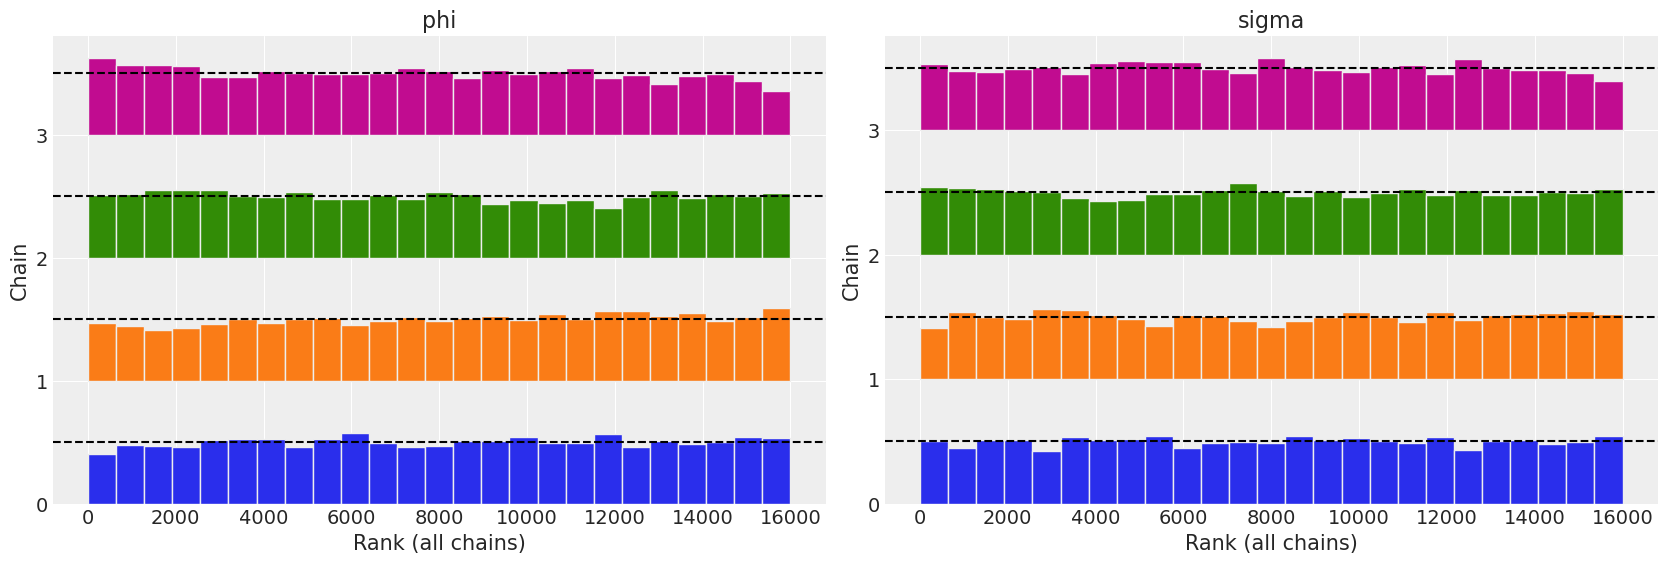

In [25]:
# Plot for specific variables (e.g., your 'phi' and 'sigma')
az.plot_rank(trace_bym, var_names=["phi", "sigma"])

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_9268/19694348.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Helps prevent label overlap


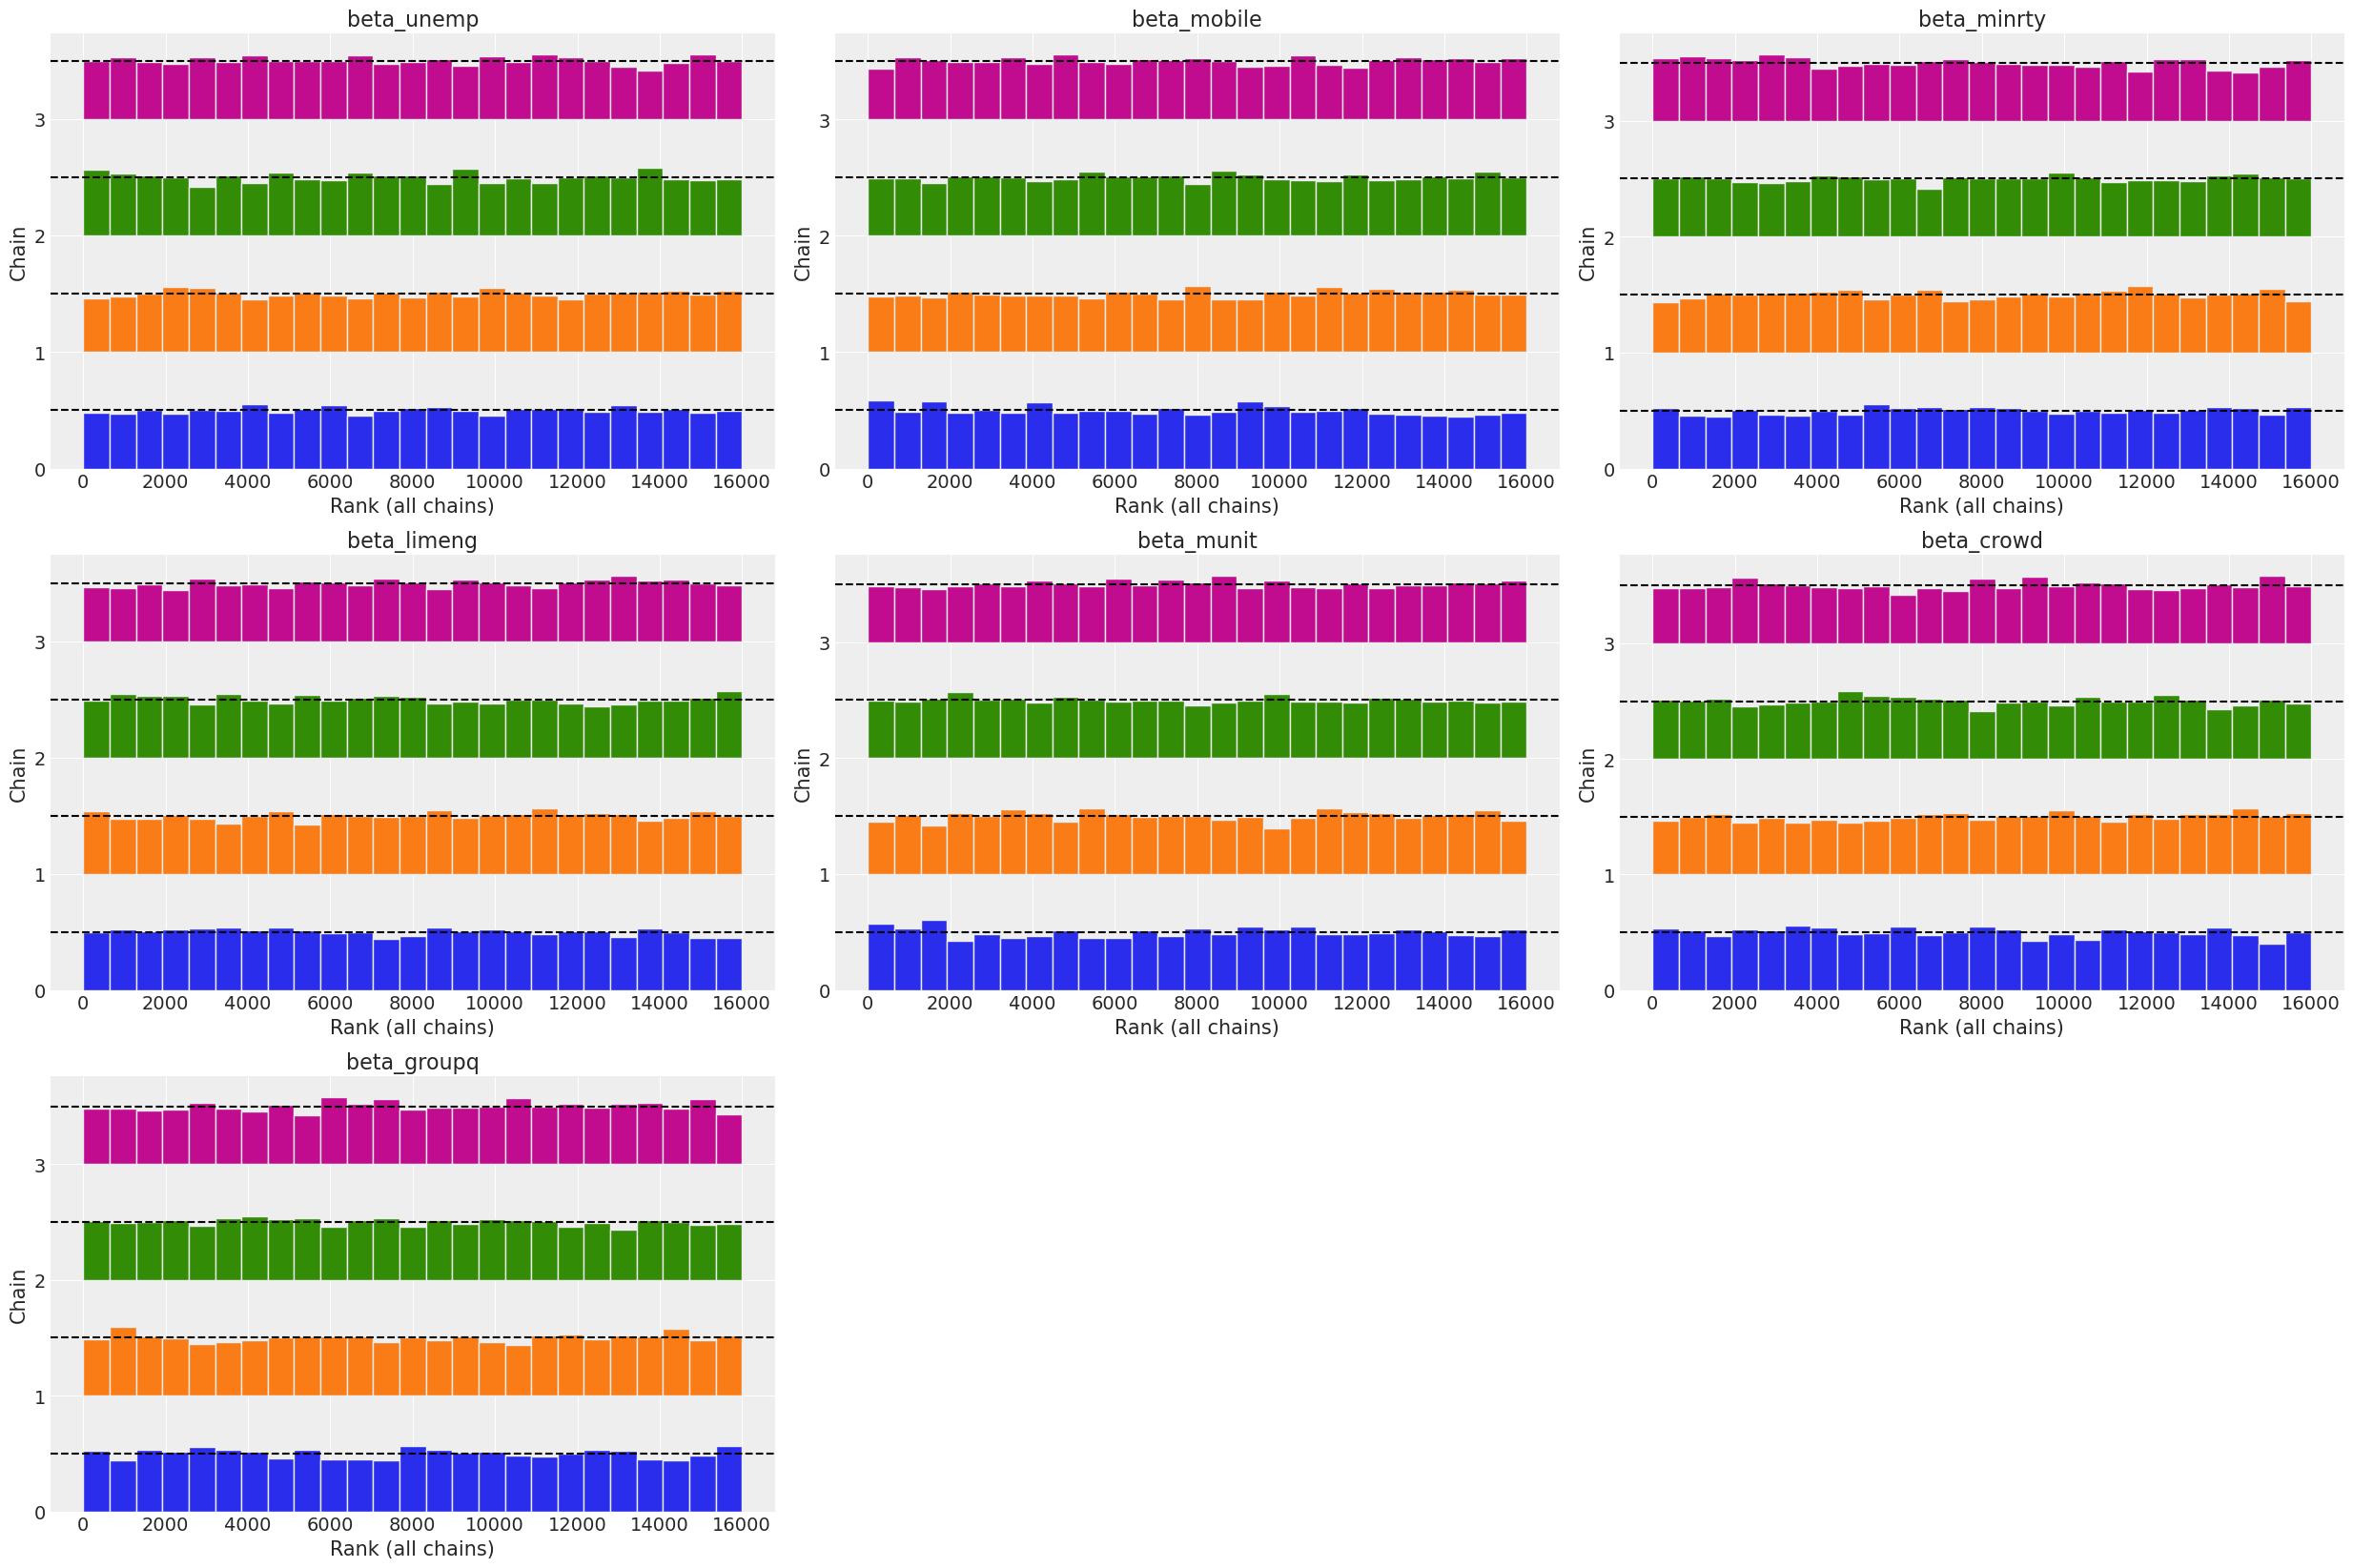

In [27]:
# plot rank plots for all coefficients
# Define coefficients to plot
coefficients = [
    "beta_unemp","beta_mobile","beta_minrty","beta_limeng","beta_munit","beta_crowd","beta_groupq"
]

# Plot all of them at once in a single grid
az.plot_rank(trace_bym, var_names=coefficients)
plt.tight_layout() # Helps prevent label overlap

Editing for the figures

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_9268/249222461.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Adjusts spacing so the larger labels don't overlap


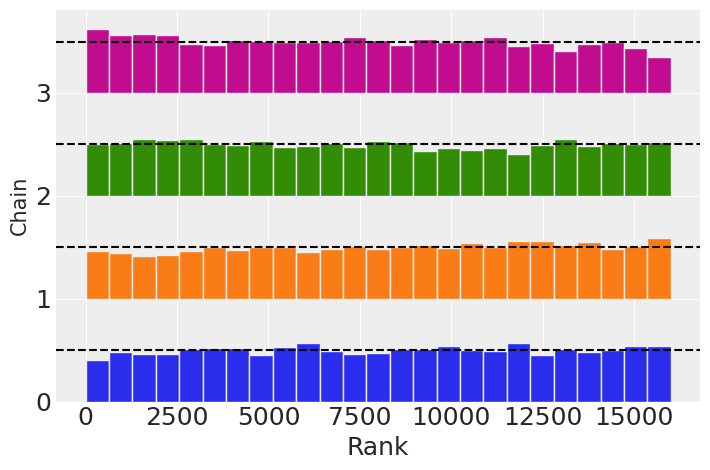

In [28]:
# Generate the plot
axes = az.plot_rank(trace_bym, var_names=["phi"])


# 1. Remove the variable name (as requested previously)
axes.set_title("")

# 2. Increase the size of the numbers (tick labels) on both axes
axes.tick_params(axis='both', which='major', labelsize=18)

# 3. (Optional) Add and size X/Y labels if you want them named
axes.set_xlabel("Rank", fontsize=18)
# ax.set_ylabel("Frequency", fontsize=16) # Rank plots usually don't label Y by default

plt.tight_layout() # Adjusts spacing so the larger labels don't overlap
# plt.show()
plt.savefig(os.path.join( save_path,"mcmc", f"phi_bym{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_9268/858212070.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Adjusts spacing so the larger labels don't overlap


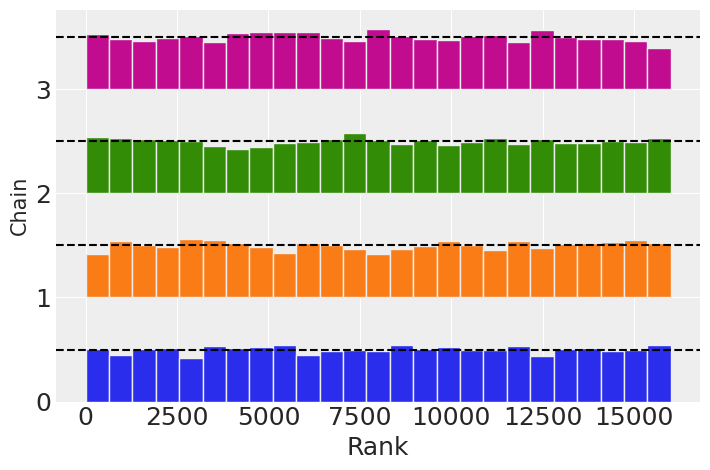

In [29]:
# Generate the plot
axes = az.plot_rank(trace_bym, var_names=["sigma"])


# 1. Remove the variable name (as requested previously)
axes.set_title("")

# 2. Increase the size of the numbers (tick labels) on both axes
axes.tick_params(axis='both', which='major', labelsize=18)

# 3. (Optional) Add and size X/Y labels if you want them named
axes.set_xlabel("Rank", fontsize=18)
# ax.set_ylabel("Frequency", fontsize=16) # Rank plots usually don't label Y by default

plt.tight_layout() # Adjusts spacing so the larger labels don't overlap
# plt.show()
plt.savefig(os.path.join( save_path,"mcmc", f"sigma_bym{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

Checking Autocorrlation

In [ ]:
az.plot_autocorr(trace_bym, var_names=["phi","sigma"], max_lag=100) 
plt.show()

Monte Carlo Error

In [30]:
summary = az.summary(trace_bym, var_names=["phi", "sigma"])
print(summary[["mean", "sd", "ess_bulk","ess_tail", "mcse_mean"]])

# save summary to csv
result_dir = os.path.join(current_path, "results", state_abb_lower)
summary.to_csv(os.path.join(result_dir, "bym_summary.csv"))

        mean     sd  ess_bulk  ess_tail  mcse_mean
phi    0.375  0.189    1451.0    3392.0      0.005
sigma  0.418  0.062    2520.0    5877.0      0.001


In [32]:
# summry all the coefficients in a single dataframe
coefficients = [
    "beta_unemp","beta_mobile","beta_minrty","beta_limeng","beta_munit","beta_crowd","beta_groupq"
]
coeff_summary = az.summary(trace_bym, var_names=coefficients)
print(coeff_summary)

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_unemp   0.091  0.870  -1.525    1.770      0.008    0.006   13100.0   
beta_mobile -0.921  0.414  -1.676   -0.136      0.005    0.003    6790.0   
beta_minrty  0.030  0.585  -1.055    1.138      0.010    0.005    3653.0   
beta_limeng -0.004  0.955  -1.834    1.733      0.007    0.007   18764.0   
beta_munit   1.135  0.920  -0.659    2.821      0.009    0.006   10194.0   
beta_crowd  -0.090  0.799  -1.594    1.390      0.007    0.006   13726.0   
beta_groupq -0.147  0.896  -1.774    1.583      0.007    0.007   15656.0   

             ess_tail  r_hat  
beta_unemp    11872.0    1.0  
beta_mobile    9953.0    1.0  
beta_minrty    7411.0    1.0  
beta_limeng   12024.0    1.0  
beta_munit    11892.0    1.0  
beta_crowd    13062.0    1.0  
beta_groupq   12145.0    1.0  


In [33]:
comparison_coeff_df = pd.DataFrame(index=coeff_summary.index)

# 2. Add the current model's means as a column
comparison_coeff_df['Model_BYM'] = coeff_summary['mean']

# Check the result
print(comparison_coeff_df.head())

             Model_BYM
beta_unemp       0.091
beta_mobile     -0.921
beta_minrty      0.030
beta_limeng     -0.004
beta_munit       1.135


Model metrics WAIC and LOO

In [34]:
loo_result_base = az.loo(trace_bym)
print(loo_result_base)

Computed from 16000 posterior samples and 91 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -246.52     9.00
p_loo       41.88        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       71   78.0%
   (0.70, 1]   (bad)        19   20.9%
   (1, Inf)   (very bad)    1    1.1%



/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [35]:
waic_result_base = az.waic(trace_bym)
print(waic_result_base)

Computed from 16000 posterior samples and 91 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -235.98     7.75
p_waic       31.34        -

There has been a warning during the calculation. Please check the results.


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


####  II. Model with new topological component (BYM-T)

In [36]:
# PyMC model for BYM
with pm.Model(coords=coords) as model_2:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_unemp = pm.Normal("beta_unemp", mu=0, sigma=1)
   beta_mobile = pm.Normal("beta_mobile", mu=0, sigma=1)
   beta_minrty = pm.Normal("beta_minrty", mu=0, sigma=1)
   beta_limeng = pm.Normal("beta_limeng", mu=0, sigma=1)
   beta_munit = pm.Normal("beta_munit", mu=0, sigma=1)
   beta_crowd = pm.Normal("beta_crowd", mu=0, sigma=1)
   beta_groupq = pm.Normal("beta_groupq", mu=0, sigma=1)

   # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # TDA effect 
   s = pm.Data("AL_effect", AL, dims="area_idx") #using the standardized AL 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", 0.39)

    # ----- Dirichlet Mixing for the three random effects -----
    # alpha = [α1, α2, α3] where:
    #   α1: weight for the iid effect (theta)
    #   α2: weight for the spatial (ICAR) effect (phi)
    #   α3: weight for the TDA effect (AL_effect)
   alpha = pm.Dirichlet("alpha", a=np.array([1.0, 1.0, 1.0]))

   # Combine the three components
   mixture = pm.Deterministic(
        "mixture",
        pt.sqrt(alpha[0]) * v +
        pt.sqrt(alpha[1] / scaling_factor) * u +
        pt.sqrt(alpha[2]) * s,
        dims="area_idx"
    )
   
   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_unemp * EP_UNEMP_AV_ORI +
                  beta_mobile * EP_MOBILE_AV_ORI +
                  beta_minrty * EP_MINRTY_AV_ORI +
                  beta_limeng * EP_LIMENG_AV_ORI +
                  beta_munit * EP_MUNIT_AV_ORI +
                  beta_crowd * EP_CROWD_AV_ORI +
                  beta_groupq * EP_GROUPQ_AV_ORI +
                   sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")

Sampling the data

In [37]:
with model_2:

    # # Sample from the model:
    trace_model_2 = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_unemp, beta_mobile, beta_minrty, beta_limeng, beta_munit, beta_crowd, beta_groupq, u, v, sigma, alpha]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 150 seconds.


R hat statistics

In [38]:
# Calculate r_hat for sigma and phi
rhat_data_model_2 = az.rhat(trace_model_2, var_names=["sigma","alpha","beta_unemp","beta_mobile","beta_minrty","beta_limeng","beta_munit","beta_crowd","beta_groupq"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data_model_2["sigma"].values}')  
print(f'R-hat for alpha: {rhat_data_model_2["alpha"].values}')

R-hat for sigma: 1.001623553860918
R-hat for alpha: [1.00094544 1.00114766 1.00032715]


In [39]:
# print rhat for all coefficients
for var in coefficients:
    print(f'R-hat for {var}: {rhat_data_model_2[var].values}')

R-hat for beta_unemp: 1.0002602428938114
R-hat for beta_mobile: 1.0002963450717903
R-hat for beta_minrty: 1.0015522461985291
R-hat for beta_limeng: 1.000513203643127
R-hat for beta_munit: 1.0000275892807002
R-hat for beta_crowd: 1.000092442660544
R-hat for beta_groupq: 1.0002224775061495


Rank plots

array([<Axes: title={'center': 'alpha\n0'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'alpha\n1'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'alpha\n2'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'sigma'}, xlabel='Rank (all chains)', ylabel='Chain'>],
      dtype=object)

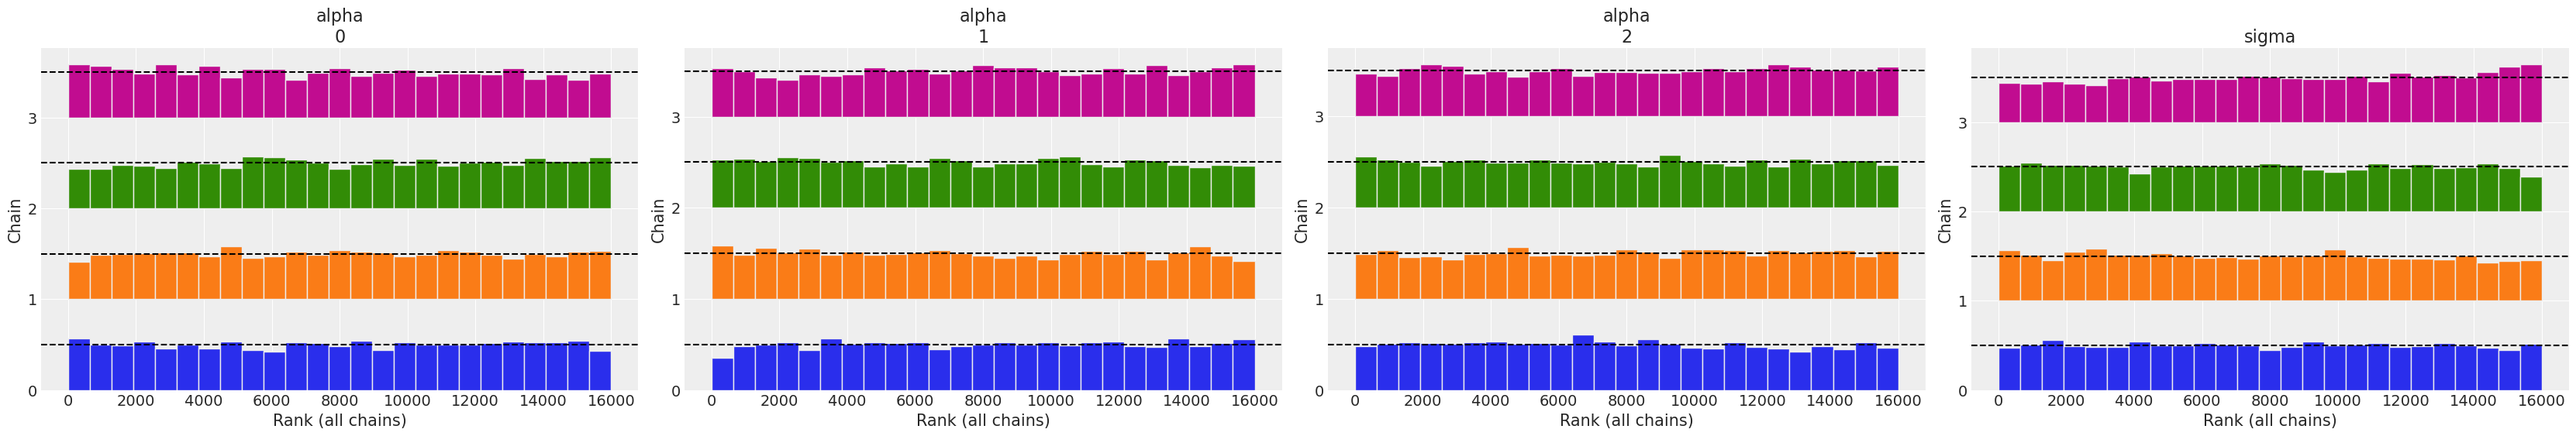

In [40]:
# Plot for specific variables (e.g., your 'phi' and 'sigma')
az.plot_rank(trace_model_2, var_names=["alpha", "sigma"])

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_9268/581698039.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Helps prevent label overlap


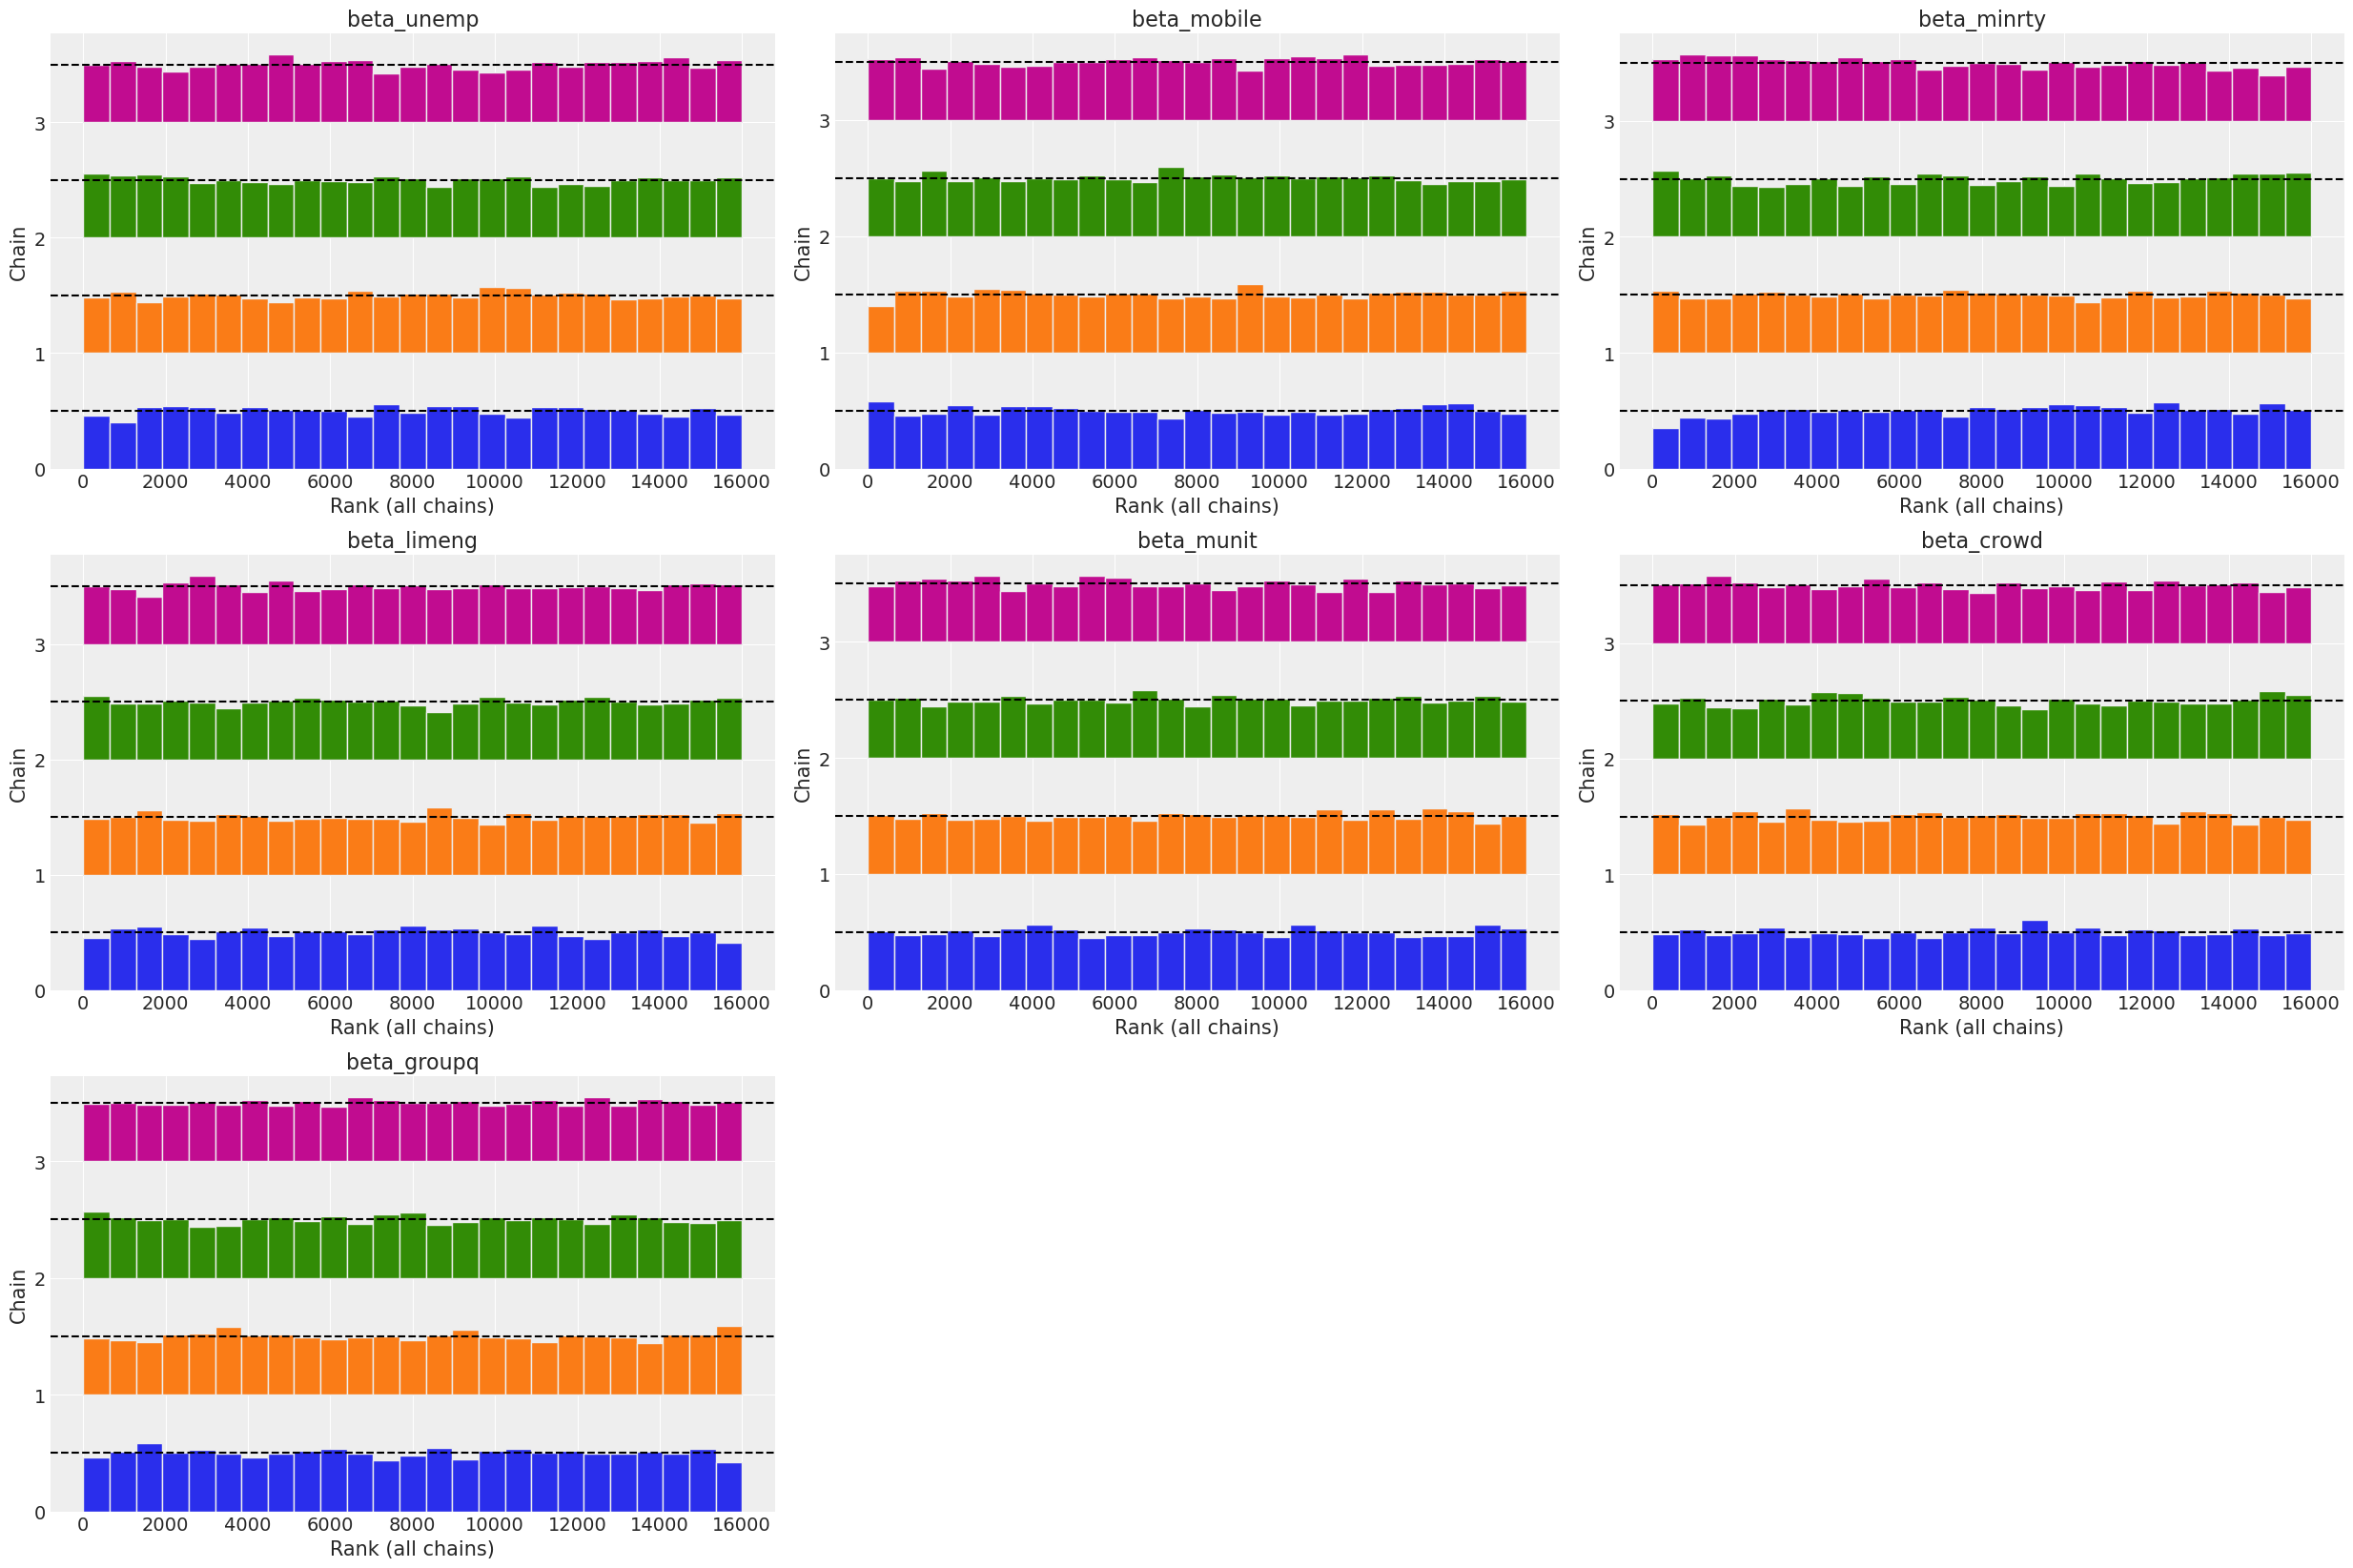

In [41]:
# plot rank plots for all coefficients

az.plot_rank(trace_model_2, var_names=coefficients)
plt.tight_layout() # Helps prevent label overlap

Editing for the figures

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_9268/4183779130.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Adjusts spacing so the larger labels don't overlap


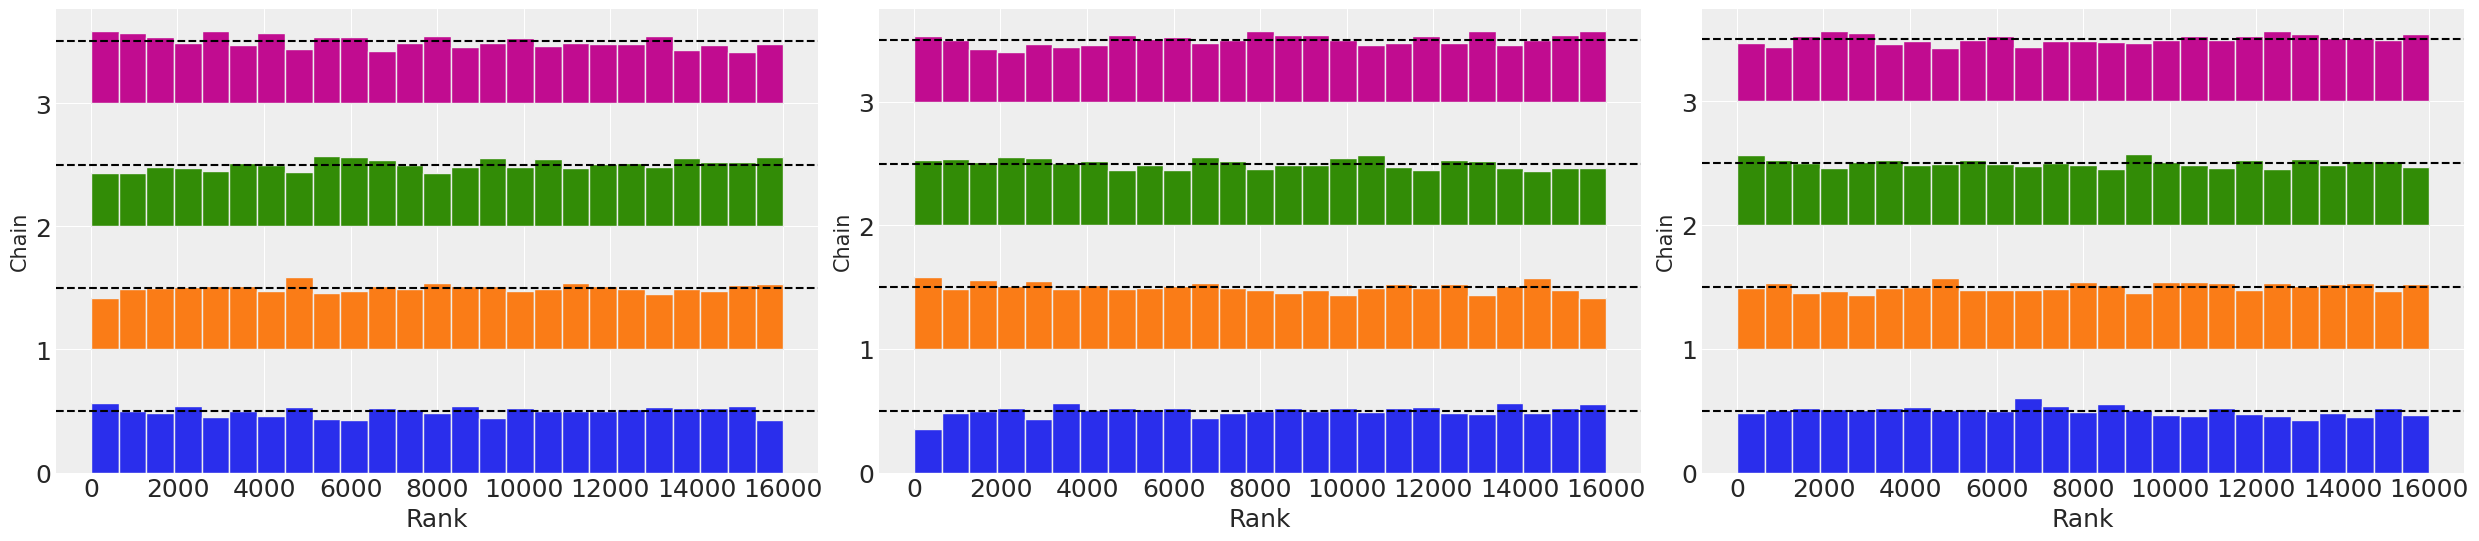

In [42]:
import arviz as az
import matplotlib.pyplot as plt

# Generate the plot
axes = az.plot_rank(trace_model_2, var_names=["alpha"])

# Iterate over each subplot to customize
for ax in axes.flatten():
    # 1. Remove the variable name (as requested previously)
    ax.set_title("")
    
    # 2. Increase the size of the numbers (tick labels) on both axes
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    # 3. (Optional) Add and size X/Y labels if you want them named
    ax.set_xlabel("Rank", fontsize=18)
    # ax.set_ylabel("Frequency", fontsize=16) # Rank plots usually don't label Y by default

plt.tight_layout() # Adjusts spacing so the larger labels don't overlap
# plt.show()
plt.savefig(os.path.join( save_path,"mcmc", f"alphas_bym_t_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_9268/3544974445.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Adjusts spacing so the larger labels don't overlap


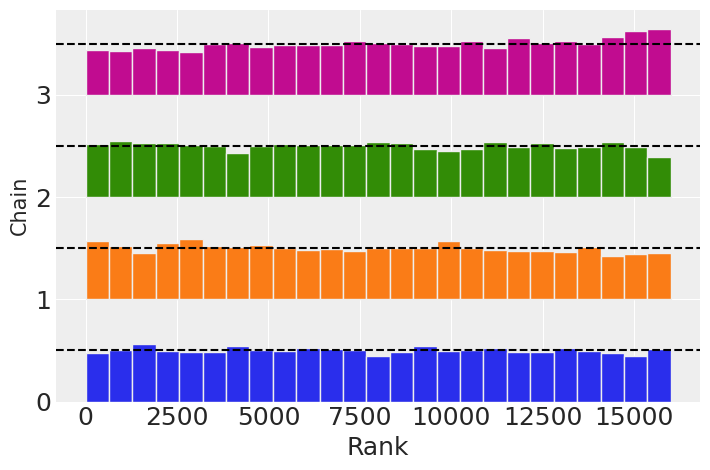

In [43]:
# Generate the plot
axes = az.plot_rank(trace_model_2, var_names=["sigma"])


# 1. Remove the variable name (as requested previously)
axes.set_title("")

# 2. Increase the size of the numbers (tick labels) on both axes
axes.tick_params(axis='both', which='major', labelsize=18)

# 3. (Optional) Add and size X/Y labels if you want them named
axes.set_xlabel("Rank", fontsize=18)
# ax.set_ylabel("Frequency", fontsize=16) # Rank plots usually don't label Y by default

plt.tight_layout() # Adjusts spacing so the larger labels don't overlap
# plt.show()
plt.savefig(os.path.join( save_path,"mcmc", f"sigma_bym_t_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

Checking Autocorrlation

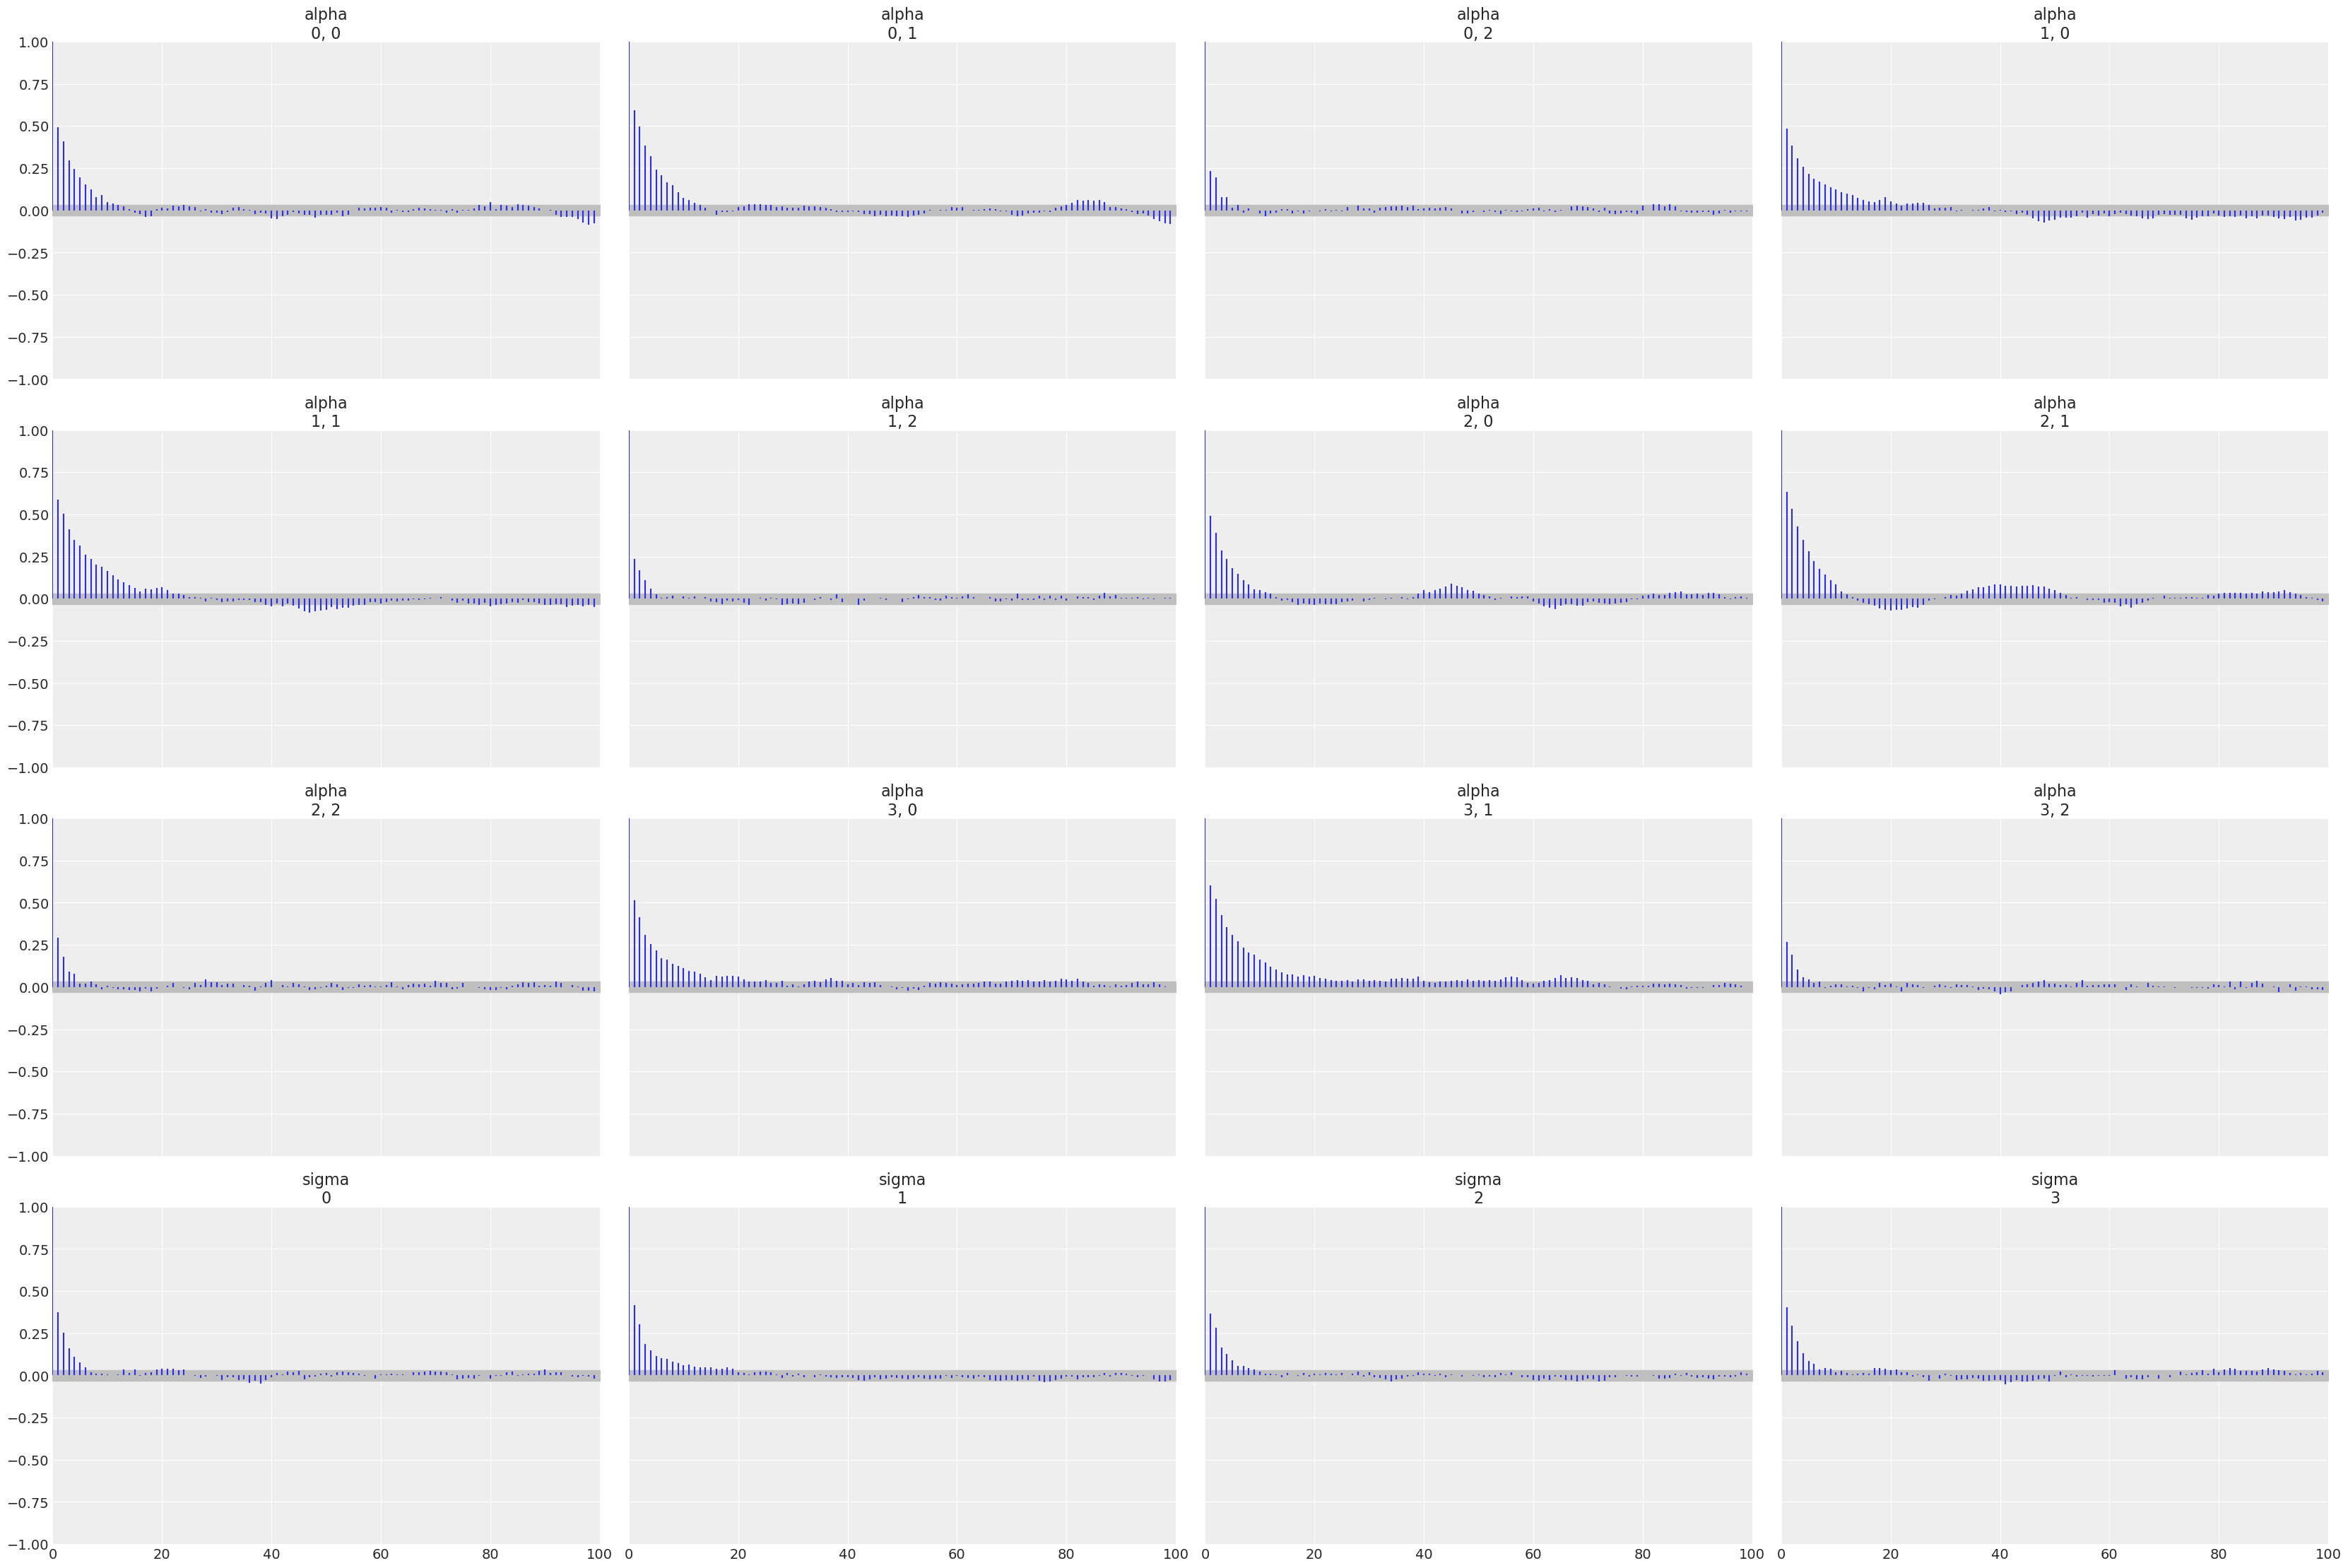

In [44]:
az.plot_autocorr(trace_model_2, var_names=["alpha","sigma"], max_lag=100) 
plt.show()

Monte Carlo Error

In [45]:
summary_model_2 = az.summary(trace_model_2, var_names=["alpha", "sigma"])
print(summary_model_2[["mean", "sd", "ess_bulk","ess_tail", "mcse_mean"]])

           mean     sd  ess_bulk  ess_tail  mcse_mean
alpha[0]  0.529  0.149    2522.0    4810.0      0.003
alpha[1]  0.218  0.153    1775.0    3371.0      0.004
alpha[2]  0.253  0.124    6705.0    9257.0      0.002
sigma     0.434  0.061    3672.0    7828.0      0.001


In [46]:
# summry all the coefficients in a single dataframe
coeff_summary_model_2 = az.summary(trace_model_2, var_names=coefficients)
print(coeff_summary_model_2)

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_unemp   0.079  0.864  -1.513    1.721      0.009    0.006   10047.0   
beta_mobile -0.333  0.436  -1.137    0.508      0.005    0.003    6580.0   
beta_minrty -0.949  0.639  -2.148    0.242      0.012    0.005    2970.0   
beta_limeng -0.223  0.950  -1.948    1.626      0.008    0.007   13928.0   
beta_munit   0.479  0.937  -1.219    2.309      0.009    0.007   10923.0   
beta_crowd  -0.041  0.801  -1.570    1.428      0.008    0.006    9290.0   
beta_groupq -0.372  0.907  -2.081    1.322      0.008    0.006   12956.0   

             ess_tail  r_hat  
beta_unemp    10569.0    1.0  
beta_mobile    8711.0    1.0  
beta_minrty    6022.0    1.0  
beta_limeng   12329.0    1.0  
beta_munit    11797.0    1.0  
beta_crowd    10803.0    1.0  
beta_groupq   12522.0    1.0  


In [47]:
# add the means to the comparison dataframe
comparison_coeff_df['model_2'] = coeff_summary_model_2['mean']

# Check the result
print(comparison_coeff_df)

             Model_BYM  model_2
beta_unemp       0.091    0.079
beta_mobile     -0.921   -0.333
beta_minrty      0.030   -0.949
beta_limeng     -0.004   -0.223
beta_munit       1.135    0.479
beta_crowd      -0.090   -0.041
beta_groupq     -0.147   -0.372


In [48]:
az.summary(trace_model_2, var_names=["sigma","alpha"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.434,0.061,0.319,0.546,0.001,0.001,3672.0,7828.0,1.0
alpha[0],0.529,0.149,0.244,0.798,0.003,0.001,2522.0,4810.0,1.0
alpha[1],0.218,0.153,0.001,0.497,0.004,0.002,1775.0,3371.0,1.0
alpha[2],0.253,0.124,0.025,0.471,0.002,0.001,6705.0,9257.0,1.0


Model metrics WAIC and LOO

In [49]:
loo_result_model_2 = az.loo(trace_model_2)
print(loo_result_model_2)

Computed from 16000 posterior samples and 91 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -246.95     9.55
p_loo       41.52        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       69   75.8%
   (0.70, 1]   (bad)        20   22.0%
   (1, Inf)   (very bad)    2    2.2%



/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [50]:
waic_result_model_2 = az.waic(trace_model_2)
print(waic_result_model_2)

Computed from 16000 posterior samples and 91 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -236.56     8.21
p_waic       31.13        -

There has been a warning during the calculation. Please check the results.


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


##### Compare model results

LOO

In [51]:
df_comp_loo = az.compare({"bym": loo_result_base,"model_2": loo_result_model_2}, ic="loo")
print(df_comp_loo)

         rank    elpd_loo      p_loo  elpd_diff    weight        se       dse  \
bym         0 -246.517381  41.880661   0.000000  0.603899  8.996995  0.000000   
model_2     1 -246.947065  41.521361   0.429684  0.396101  9.545403  1.927638   

         warning scale  
bym         True   log  
model_2     True   log  


WAIC

In [52]:
df_comp_waic = az.compare({"bym": waic_result_base, "model_2": waic_result_model_2}, ic="waic")
print(df_comp_waic)

         rank   elpd_waic     p_waic  elpd_diff    weight        se      dse  \
bym         0 -235.979857  31.343136   0.000000  0.713833  7.748079  0.00000   
model_2     1 -236.558035  31.132331   0.578178  0.286167  8.213496  1.62209   

         warning scale  
bym         True   log  
model_2     True   log  


Get sample values to plot the map

In [53]:
rr_bym = trace_bym.posterior["rr"].mean(dim=["chain", "draw"]).values
rr_model_2 = trace_model_2.posterior["rr"].mean(dim=["chain", "draw"]).values

In [54]:
combined_data["rr_bym"] = rr_bym
combined_data["rr_model_2"] = rr_model_2

In [55]:
# lets get the differences to base rr_bym
combined_data["rr_diff_bym_model_2"] = combined_data["rr_model_2"] - combined_data["rr_bym"]

In [56]:
# let's add missing islands and overdose missing areas back with NaN values
geo_data_for_the_area = geo_data[geo_data['ST_ABBR']==state_abb]

# merge combined_data with geo_data_for_the_area to get all FIPS codes (with NULL values for missing areas)
combined_data_full = geo_data_for_the_area.merge(combined_data, on="FIPS", how="left")

# make combined data into a geodataframe
combined_data_full = gpd.GeoDataFrame(combined_data_full, geometry='geometry_x')

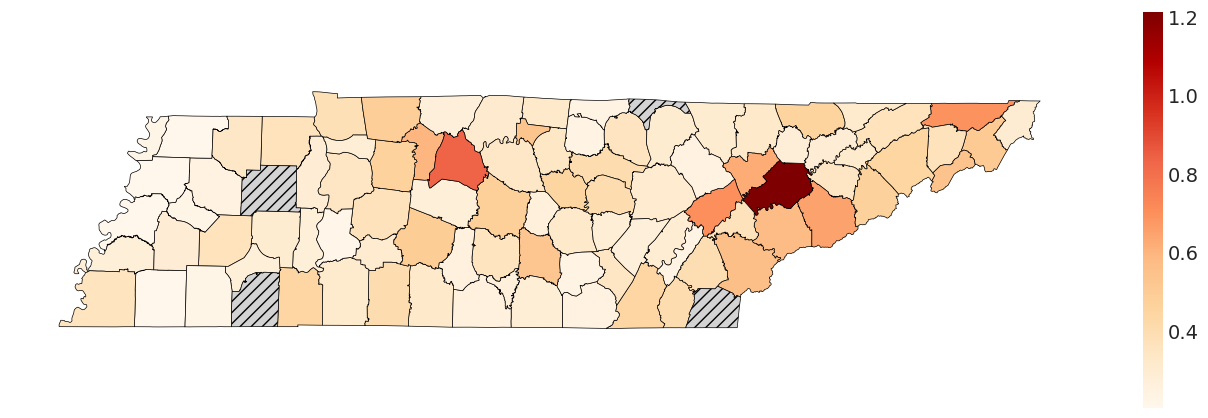

In [57]:
# plot a map with the relative risk for the BYM model
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

combined_data_full.plot(
    column="rr_bym", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"bym_relative_risk_map.png"), bbox_inches='tight', dpi=300)

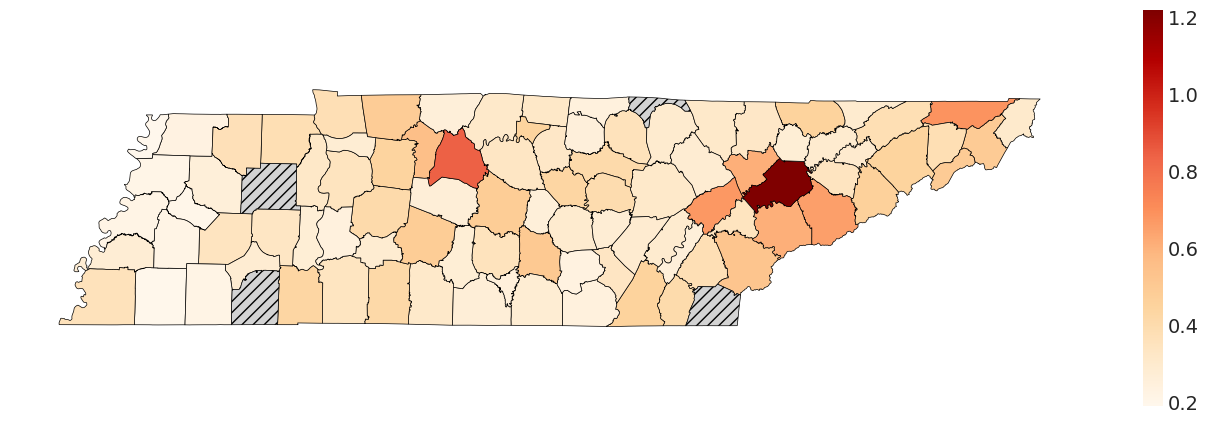

In [58]:
# plot a map with the relative risk for the model 2
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

combined_data_full.plot(
    column="rr_model_2", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( save_path, f"bymt_relative_risk_map_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

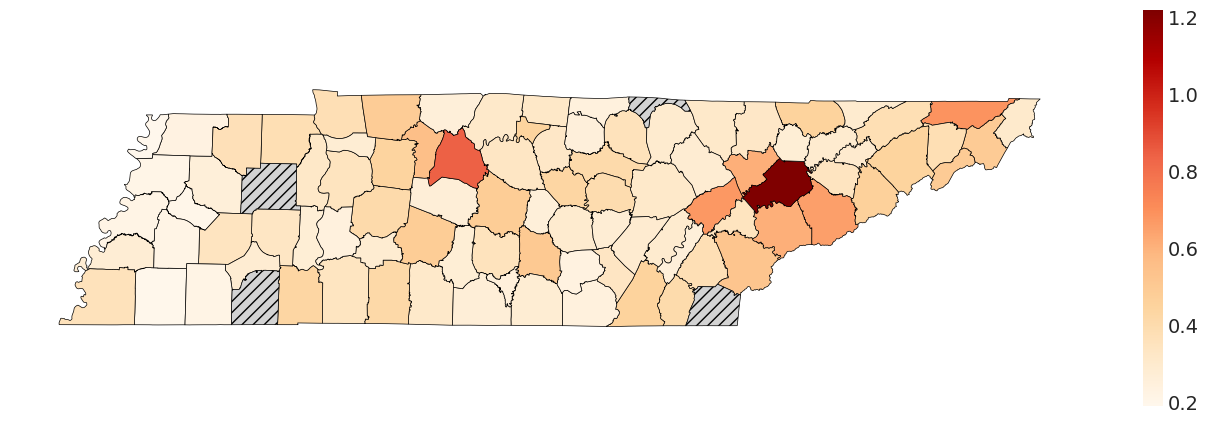

In [59]:
# plot a map with the relative risk for the model 2
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

combined_data_full.plot(
    column="rr_model_2", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"bymt_relative_risk_map.png"), bbox_inches='tight', dpi=300)

Plot the differences

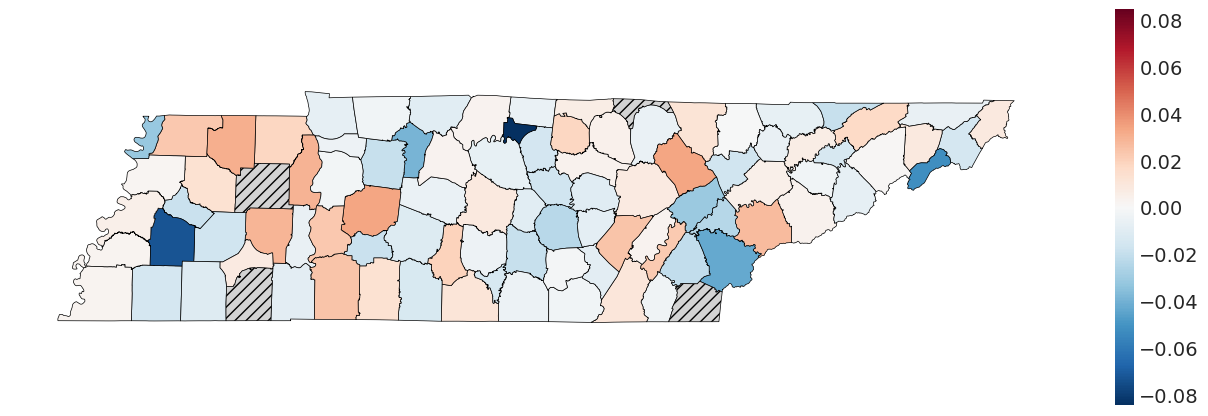

In [60]:
# plot a map with the relative risk for the BYM-T and the BYM model
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

# Find min/max of your column
vmin = combined_data_full["rr_diff_bym_model_2"].min()
vmax = combined_data_full["rr_diff_bym_model_2"].max()

# Create symmetric range around 0
abs_max = max(abs(vmin), abs(vmax))

combined_data_full.plot(
    column="rr_diff_bym_model_2", 
    ax=ax, 
    legend=True, 
    cmap="RdBu_r", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    vmin=-abs_max,  # ensure 0 is at center
    vmax=abs_max,
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( save_path, f"relative_risk_difference_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

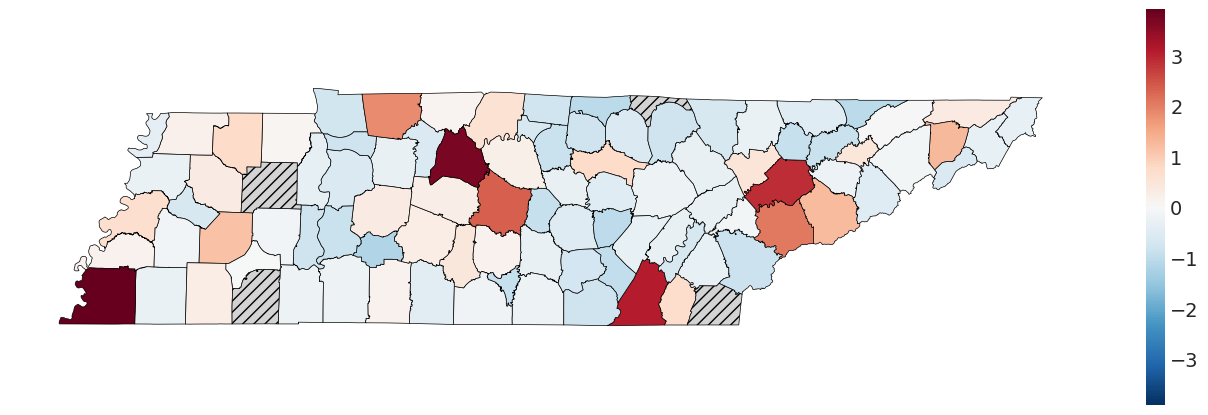

In [61]:
# plot a map with AL values for each area
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white


# Find min/max of your column
almin = combined_data_full["AL"].min()
almax = combined_data_full["AL"].max()

# Create symmetric range around 0
abs_max_al = max(abs(almin), abs(almax))

combined_data_full.plot(
    column="AL", 
    ax=ax, 
    legend=True, 
    cmap="RdBu_r", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    vmin=-abs_max_al,  # ensure 0 is at center
    vmax=abs_max_al,
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

plt.savefig(os.path.join( save_path, f"AL_SCALED_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

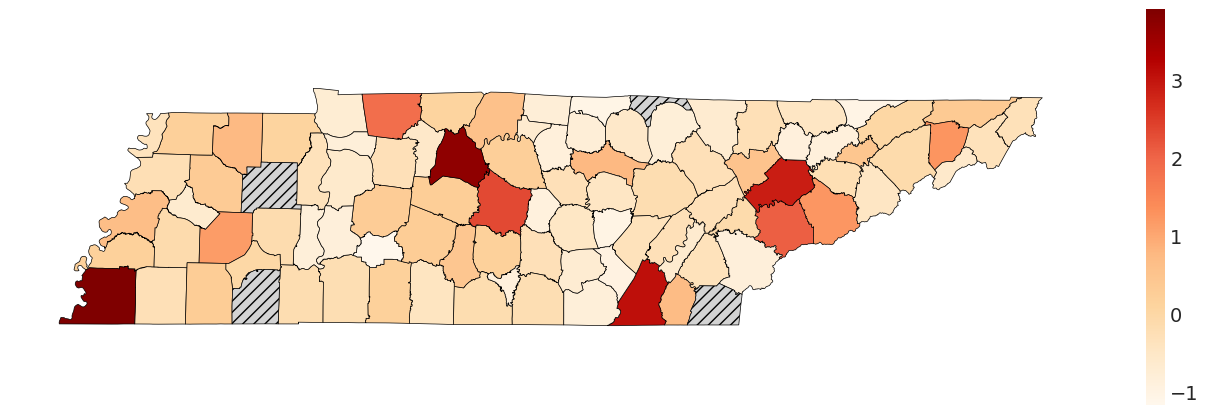

In [62]:
# plot a map with AL values for each area
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white


combined_data_full.plot(
    column="AL", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"AL_map.png"), bbox_inches='tight', dpi=300)

Coefficients comparisons

In [63]:
comparison_coeff_df = comparison_coeff_df.rename(columns={
    "Model_BYM": "BYM",
    "model_2": "BYM-T"
})


In [64]:
comparison_coeff_df = comparison_coeff_df.rename(index={
    "beta_pov": "Poverty rate",
    "beta_unemp": "Unemployment rate",
    "beta_pci": "Per capita income",
    "beta_nohsdp": "No high school diploma",
    "beta_age65": "Population aged 65+",
    "beta_age17": "Population aged ≤17",
    "beta_disabl": "Disability prevalence",
    "beta_sngpnt": "Single-parent households",
    "beta_minrty": "Minority population",
    "beta_limeng": "Limited English proficiency",
    "beta_munit": "Multi-unit housing",
    "beta_mobile": "Mobile homes",
    "beta_crowd": "Household crowding",
    "beta_noveh": "No vehicle access",
    "beta_groupq": "Group quarters population",
})


In [65]:
comparison_coeff_df

,BYM,BYM-T
Unemployment rate,0.091,0.079
Mobile homes,-0.921,-0.333
Minority population,0.030,-0.949
Limited English proficiency,-0.004,-0.223
Multi-unit housing,1.135,0.479
Household crowding,-0.090,-0.041
Group quarters population,-0.147,-0.372


/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_9268/3572415688.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


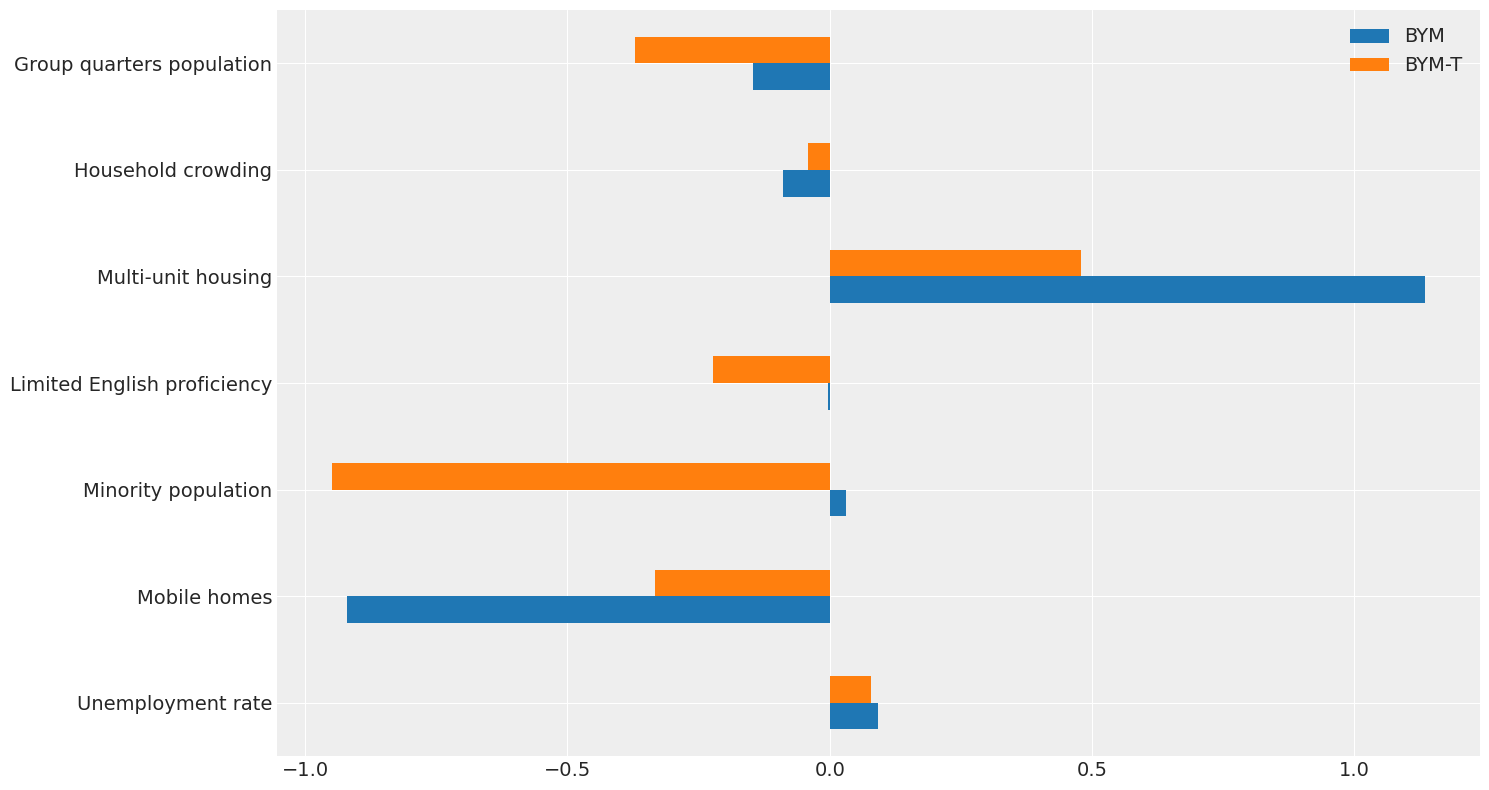

In [66]:
comparison_coeff_df.plot(
    kind='barh',
    figsize=(15, 8),
    color=["#1f77b4", "#ff7f0e"]  # blue, orange
)
# plt.xlabel('Coefficient Mean Estimates')
# plt.title('Comparison of Coefficient Estimates Across Models')
plt.tight_layout()
# plt.show()

plt.savefig(os.path.join( save_path, f"coeff_comparison_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_9268/3157777422.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


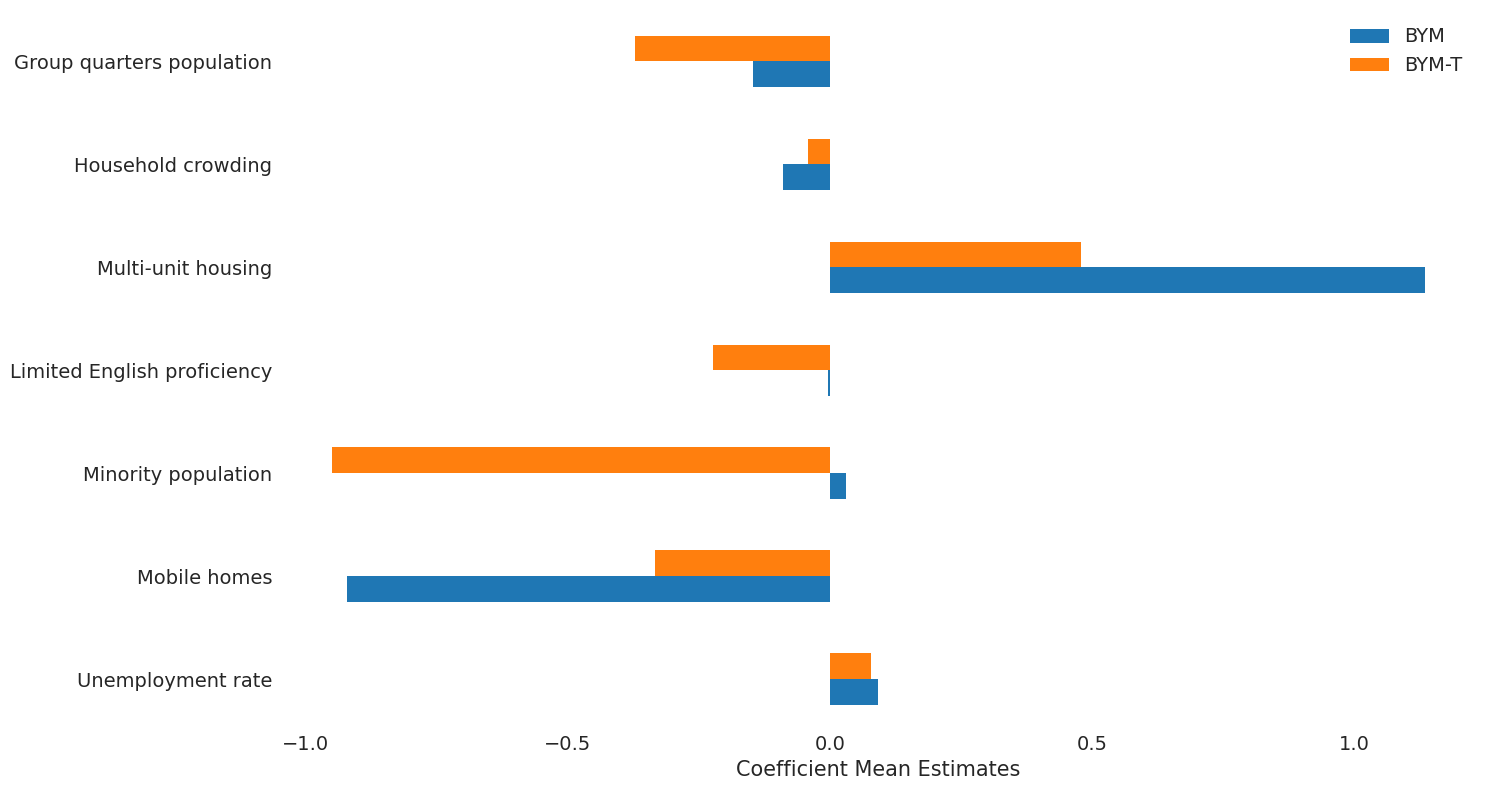

In [67]:
import matplotlib.pyplot as plt

# Assuming comparison_coeff_df is already defined
ax = comparison_coeff_df.plot(
    kind='barh',
    figsize=(15, 8),
    color=["#1f77b4", "#ff7f0e"]  # blue, orange
)

# Set the figure and axes background to white
fig = plt.gcf()
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Labels and Title
plt.xlabel('Coefficient Mean Estimates')
# plt.title('Comparison of Coefficient Estimates Across Models')

plt.tight_layout()
plt.savefig(os.path.join( save_path, f"coeff_comparison_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

Comparison of sigma, phi, alpha

In [68]:
# bym model sigma and phi model diagnostics
print(summary[["mean", "sd", "ess_bulk","ess_tail", "mcse_mean"]])

        mean     sd  ess_bulk  ess_tail  mcse_mean
phi    0.375  0.189    1451.0    3392.0      0.005
sigma  0.418  0.062    2520.0    5877.0      0.001


In [69]:
# model 2 sigma and alpha model diagnostics
print(summary_model_2[["mean", "sd", "ess_bulk","ess_tail", "mcse_mean"]])

           mean     sd  ess_bulk  ess_tail  mcse_mean
alpha[0]  0.529  0.149    2522.0    4810.0      0.003
alpha[1]  0.218  0.153    1775.0    3371.0      0.004
alpha[2]  0.253  0.124    6705.0    9257.0      0.002
sigma     0.434  0.061    3672.0    7828.0      0.001


In [70]:
# generate a dataframe with FIPS, rr_bym, rr_model_2, rr_diff_bym_model_2 and the percentage change between rr_bym and rr_model_2
results_df = combined_data_full[["FIPS", "rr_bym", "rr_model_2", "rr_diff_bym_model_2", "AL"]].copy()
results_df["Relative Difference Percentage"] = (results_df["rr_model_2"] - results_df["rr_bym"]) / results_df["rr_bym"] * 100

In [71]:
# sort by percentage change descending
results_df = results_df.sort_values(by="Relative Difference Percentage", ascending=False)

In [72]:
results_df

,FIPS,rr_bym,rr_model_2,rr_diff_bym_model_2,AL,Relative Difference Percentage
90,47129,0.248891,0.282106,0.033214,-0.288193,13.344962
34,47131,0.208760,0.231710,0.022950,0.195508,10.993421
84,47135,0.218075,0.240852,0.022777,-0.855626,10.444524
53,47005,0.289762,0.319347,0.029585,-0.341122,10.210130
76,47121,0.235726,0.257971,0.022245,-0.659891,9.436590
...,...,...,...,...,...,...
73,47075,0.288844,0.215777,-0.073067,-0.141919,-25.296409
36,47139,NaN,NaN,NaN,NaN,NaN
54,47017,NaN,NaN,NaN,NaN,NaN
62,47109,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 1. Drop NaNs to ensure accurate counts
df_clean = results_df.dropna(subset=["AL", "Relative Difference Percentage"]).copy()

# 2. Assign categories based on the sign (> 0 or < 0)
# We use np.select to handle Pos, Neg, and Zero cleanly
conditions_pov = [df_clean["AL"] > 0, df_clean["AL"] < 0]
choices_pov = ["Positive", "Negative"]
df_clean["AL_Sign"] = np.select(conditions_pov, choices_pov, default="Zero")

conditions_diff = [df_clean["Relative Difference Percentage"] > 0, df_clean["Relative Difference Percentage"] < 0]
choices_diff = ["Positive", "Negative"]
df_clean["Diff_Sign"] = np.select(conditions_diff, choices_diff, default="Zero")

# 3. Create a Crosstab (Contingency Table)
# This counts the overlaps between POV signs and Difference signs
summary = pd.crosstab(df_clean["AL_Sign"], df_clean["Diff_Sign"])

# 4. Calculate Conditional Percentages (Row Percentages)
# "Out of all Positive POV, how many were Positive Diff?"
# axis=0 divides by column totals, axis=1 divides by row totals. We want row totals.
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

# 5. formatting for display
# Combine Count and Percentage into one string for easier reading
summary_combined = summary.astype(str) + " (" + summary_pct.round(1).astype(str) + "%)"

print("--- Summary of Signs (AL vs Relative Diff) ---")
print("Format: Count (Percentage of that POV Group)\n")
print(summary_combined)

# If you prefer a flat table with explicit labels:
print("\n--- Detailed Flat Summary ---")
flat_summary = []
for al_type in ["Positive", "Negative"]:
    total_in_group = summary.loc[al_type].sum()
    for diff_type in ["Positive", "Negative"]:
        count = summary.loc[al_type, diff_type]
        pct = (count / total_in_group) * 100 if total_in_group > 0 else 0
        
        status = "MATCH" if al_type == diff_type else "MISMATCH"
        
        flat_summary.append({
            "AL Sign": al_type,
            "Diff Percentage Sign": diff_type,
            "Type": status,
            "Count": count,
            "Percentage (of POV group)": f"{pct:.1f}%"
        })

print(pd.DataFrame(flat_summary))

In [ ]:
import matplotlib.pyplot as plt

# 1. Figure setup
plt.figure(figsize=(10, 6), facecolor='white')

# 2. Plot the histogram
plt.hist(results_df["Relative Difference Percentage"].dropna(), bins=30, color="#1f77b4", edgecolor="black", alpha=0.7)

# 3. Force background white (removes gray background from styles like seaborn)
plt.gca().set_facecolor('white')

# 4. REMOVE GRID LINES
plt.grid(False) # This overrides any default styles that might be adding grids automatically

# plt.title("Histogram of Relative Difference Percentage (BYM-T vs BYM)")
plt.xlabel("Relative Difference Percentage (%)")
plt.ylabel("Frequency")

plt.savefig(os.path.join( save_path, f"relative_difference_percentage_histogram_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

In [ ]:
# get the FIPS codes and their relative difference percentages for areas where the relative difference percentage is greater than 10% and less than -10%
significant_changes = results_df[(results_df["Relative Difference Percentage"] > 10) | (results_df["Relative Difference Percentage"] < -10)]
significant_changes = significant_changes[["FIPS", "Relative Difference Percentage","AL"]]

# add a new column to significant_changes with the direction of change
def change_direction(x):
    if x > 0:
        return "Increase"
    else:
        return "Decrease"
significant_changes["Change Direction"] = significant_changes["Relative Difference Percentage"].apply(change_direction)

print(significant_changes)


In [ ]:
# import svi geodata
svi_geo_data = gpd.read_file("/Users/h6x/CODE/Archive/git/spatial-risk-tda/data/processed_data/USA_SVI_2018_WV_cleaned_scaled.gdb", dtype={"FIPS": str})

Decreasing areas with 0-1 scale

In [ ]:

for fips in significant_changes[significant_changes["Change Direction"] == "Decrease"]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]

    print(f"Plotting SVI data for FIPS: {fips}")
    print(f"AL - Min: {svi_temp_area['AL'].min()}, Max: {svi_temp_area['AL'].max()}")

    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')
    ax.set_facecolor("white")

    svi_temp_area.plot(
        column="AL", 
        ax=ax, 
        legend=True, 
        cmap="OrRd", 
        
        # --- KEY CHANGE HERE ---
        vmin=0,   # Anchor the bottom of the color scale at 0
        vmax=1,   # Anchor the top of the color scale at 1
        # -----------------------
        
        edgecolor="black", 
        linewidth=0.5,
        legend_kwds={"shrink": 0.5},
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "No Data"
        }
    )   
    
    ax.set_xticks([])
    ax.set_yticks([])   
    # plt.show()

    # plt.savefig(os.path.join( save_path,"0_1_scale", f"EP_POV_{fips}_decreasing.png"), bbox_inches='tight', dpi=300)
    plt.show()

Increasing ing areas with 0-1 scale

In [ ]:

for fips in significant_changes[significant_changes["Change Direction"] == "Increase"]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]

    print(f"Plotting SVI data for FIPS: {fips}")
    print(f"AL - Min: {svi_temp_area['AL'].min()}, Max: {svi_temp_area['AL'].max()}")

    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')
    ax.set_facecolor("white")

    svi_temp_area.plot(
        column="AL", 
        ax=ax, 
        legend=True, 
        cmap="OrRd", 
        
        # --- KEY CHANGE HERE ---
        vmin=0,   # Anchor the bottom of the color scale at 0
        vmax=1,   # Anchor the top of the color scale at 1
        # -----------------------
        
        edgecolor="black", 
        linewidth=0.5,
        legend_kwds={"shrink": 0.5},
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "No Data"
        }
    )   
    
    ax.set_xticks([])
    ax.set_yticks([])   
    # plt.savefig(os.path.join( save_path,"0_1_scale", f"EP_POV_{fips}_increasing.png"), bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:
al_col_names_selected = [
    "EP_UNEMP_AL",
    "EP_AGE65_AL",
    "EP_MINRTY_AL",
    "EP_LIMENG_AL",
    "EP_MUNIT_AL",
    "EP_CROWD_AL",
    "EP_GROUPQ_AL"
]

In [ ]:
# plot box plots for all AL components in single figure
plt.figure(figsize=(12, 8))
combined_data.boxplot(column=al_col_names_selected)
plt.title("Box Plots of AL Components")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
# plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"AL_components_boxplots.png"), bbox_inches='tight', dpi=300)
plt.show()